# Validation-TP Mask-vs.-Delete Ablation Study

This notebook performs the preliminary **ablation-operator selection study** on **all validation-set true positives**. The choice between masking and deletion is therefore made before the held-out test-set method evaluation.

The study uses heterogeneous span sources without selecting their configuration from mask-vs.-delete outcomes:

- **Random spans:** one fixed mid-range configuration with repeated random samples.
- **Attention spans:** one configuration sampled reproducibly from the predefined sparse configuration space.
- **SHAP spans:** the same quantile/window setup in two symmetric explanation runs, one with a `[MASK]` SHAP masker and one with a deletion SHAP masker.
- **MIL spans:** one uniform random draw from predefined space max-pooling setup trained on the training split only.

SHAP is a post-hoc attribution method and has no training phase; the two SHAP conditions are separate **explanation runs**. Within each resulting span source, the selected character spans are fixed and then evaluated once with masking and once with deletion.

The existing LLM silver reference is intentionally not used in this primary operator-selection study because it was generated for test-set true positives. This keeps the design decision entirely on validation data.

The downstream evaluation logic remains the same as in the previous mask-vs.-delete notebook: probability drop, positive-drop rate, prediction flips, bootstrap confidence intervals, paired differences, Wilcoxon signed-rank tests, and paired visualizations.

## Experimental principle

For an original argument $x_i$ and a fixed set of selected spans $S_{m,i}$ from span source $m$, the notebook constructs

$$
x^{\mathrm{mask}}_{m,i}\quad\text{and}\quad x^{\mathrm{delete}}_{m,i}
$$

from exactly the same original character spans. The probability drop is

$$
\Delta p_{a,m,i}
=
p_{\mathrm{inappropriate}}(x_i)
-
p_{\mathrm{inappropriate}}\left(x^a_{m,i}\right),
\qquad a\in\{\mathrm{mask},\mathrm{delete}\}.
$$

A positive value means that perturbing the selected information lowers the predicted probability of inappropriateness. Masking is standardized across span sources by replacing every classifier token covered by a selected character span with one `[MASK]` token. Deletion removes the same selected character spans completely.

In [6]:
from __future__ import annotations

import gc
import itertools
import json
import math
import random
import re
import string
import sys
import warnings
from pathlib import Path
from typing import Any, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer, pipeline

try:
    import shap
except ImportError as exc:
    raise ImportError('SHAP is required. Install the project requirements first.') from exc

try:
    from scipy.stats import wilcoxon
except ImportError:
    wilcoxon = None
    warnings.warn('scipy is unavailable; Wilcoxon tests will be skipped.')

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 180)

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").is_dir():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Could not locate the project root containing the 'src' directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import load_prepared_splits

In [19]:
# Reproducibility and common settings.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = 'timonziegenbein/appropriateness-classifier-binary'
TEXT_COL = 'post_text'
TEXT_NORM_COL = 'text_norm'
LABEL_COL = 'Inappropriateness'
ID_COL = 'post_id'
MAX_LENGTH = 512
CLASSIFIER_BATCH_SIZE = 32
PREDICTION_THRESHOLD = 0.5
N_BOOTSTRAP = 2_000

# Requested output structure.
OUTPUT_DIR = PROJECT_ROOT / 'results/ablation_comparison'
PLOT_DIR = OUTPUT_DIR / 'plots'
TABLE_DIR = OUTPUT_DIR / 'tables'
CACHE_DIR = OUTPUT_DIR / 'cache'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
for directory in (OUTPUT_DIR, PLOT_DIR, TABLE_DIR, CACHE_DIR, CHECKPOINT_DIR):
    directory.mkdir(parents=True, exist_ok=True)

# Device: CUDA -> MPS -> CPU.
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

# Fixed Random configuration: midpoint of the existing span-length grid.
RANDOM_SELECTION_MODE = 'single_contiguous'
RANDOM_SPAN_LENGTH = 10
RANDOM_SAMPLES_PER_ARGUMENT = 5

# User-provided Attention space; sample exactly one configuration before evaluation.
ATTENTION_METHODS = ['last_cls', 'rollout']
QUANTILE_VALUES = [0.3, 0.4, 0.50, 0.60, 0.70, 0.80, 0.85, 0.90, 0.95]
WINDOW_SIZE_VALUES = [0, 1, 2, 3]
ATTENTION_CONFIG_SPACE = list(itertools.product(ATTENTION_METHODS, QUANTILE_VALUES, WINDOW_SIZE_VALUES))
ATTENTION_METHOD, ATTENTION_QUANTILE, ATTENTION_WINDOW_SIZE = random.Random(SEED).choice(ATTENTION_CONFIG_SPACE)

# Symmetric SHAP sensitivity setup.
SHAP_QUANTILE = 0.50
SHAP_WINDOW_SIZE = 0
SHAP_BATCH_SIZE = 8
SHAP_MASKER_MODES = ['mask', 'delete']
OVERWRITE_SHAP_CACHE = False

# Lightweight fixed MIL setup with one randomly sampled span configuration.
SINGLE_SPAN_LENGTH_VALUES = [5, 8, 10, 12, 15]
STRIDE_VALUES = [2, 4]
MIL_CONFIG_SPACE = list(itertools.product(SINGLE_SPAN_LENGTH_VALUES,STRIDE_VALUES))
MIL_CONFIG = random.Random(SEED).choice(MIL_CONFIG_SPACE)
MIL_SPAN_LENGTH, MIL_STRIDE = MIL_CONFIG
MIL_SPAN_LENGTHS = (MIL_SPAN_LENGTH,)

# All remaining MIL parameters are held fixed.
MIL_POOLING_MODE = "max"
MIL_MAX_CANDIDATES = 50
MIL_MIN_WORDS = 2
MIL_NUM_EPOCHS = 2
MIL_FREEZE_ENCODER = True
MIL_MAX_LENGTH = 96
MIL_ENCODER_CHUNK_SIZE = 16 if DEVICE.type == "cuda" else 8
MIL_HEAD_LR = 1e-3
MIL_WEIGHT_DECAY = 0.01
MIL_GRAD_CLIP_NORM = 1.0
MIL_INITIAL_INSTANCE_PROB = 0.02
MIL_TOP_N_SPANS = 3
MIL_OVERWRITE_CHECKPOINT = False

print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print('CUDA device:', torch.cuda.get_device_name(0))
print('Random config:', RANDOM_SELECTION_MODE, RANDOM_SPAN_LENGTH, 'samples=', RANDOM_SAMPLES_PER_ARGUMENT)
print('Attention sampled config:', ATTENTION_METHOD, ATTENTION_QUANTILE, ATTENTION_WINDOW_SIZE)
print('SHAP config:', SHAP_QUANTILE, SHAP_WINDOW_SIZE, SHAP_MASKER_MODES)
print('MIL config:', MIL_POOLING_MODE, MIL_SPAN_LENGTHS, 'stride=', MIL_STRIDE, 'epochs=', MIL_NUM_EPOCHS)
print('Output:', OUTPUT_DIR)

Device: mps
Random config: single_contiguous 10 samples= 5
Attention sampled config: last_cls 0.6 2
SHAP config: 0.5 0 ['mask', 'delete']
MIL config: max (5,) stride= 4 epochs= 2
Output: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison


## 1. Validation true positives

All available validation true positives are used. No validation argument subsampling is performed.

In [8]:
df_all, train_df, val_df, test_df = load_prepared_splits()
val_tp_df = val_df.loc[val_df['confusion_type'].astype(str).str.upper().eq('TP')].copy().reset_index(drop=True)

if val_tp_df.empty:
    raise RuntimeError('No validation true positives were found.')

required = ['global_row_id', 'split', TEXT_NORM_COL, LABEL_COL, 'p_inappropriate_original', 'predicted_label', 'confusion_type']
missing = [column for column in required if column not in val_tp_df.columns]
if missing:
    raise KeyError(f'Prepared validation data is missing columns: {missing}')

print('Train arguments:', len(train_df))
print('Validation arguments:', len(val_df))
print('Validation true positives:', len(val_tp_df))
print('Test arguments (not used here):', len(test_df))
display(val_tp_df[['global_row_id', ID_COL, 'issue', TEXT_NORM_COL, LABEL_COL, 'p_inappropriate_original', 'predicted_label', 'confusion_type']].head())

Train arguments: 1533
Validation arguments: 220
Validation true positives: 88
Test arguments (not used here): 438


,global_row_id,post_id,issue,text_norm,Inappropriateness,p_inappropriate_original,predicted_label,confusion_type
0,1533,28,Pro choice vs pro life:,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",1,0.998432,LABEL_1,TP
1,1534,29,Pro choice vs pro life:,Who are we to judge what is right or wrong? Can we not just let people make decisions and live with the consequences?,1,0.994887,LABEL_1,TP
2,1538,112,"Cmv: i think abortion is an acceptable choice, and i think it's ridiculous that it's looked down upon.:","All my life I've grown up around religious people, always telling me abortion was wrong, murder, and immoral. But I slowly realized, it's not really a fully formed human, how c...",1,0.998134,LABEL_1,TP
3,1539,114,Cmv i believe human civilization is doomed. *please* change my view.:,"Well, I hate to be a downer, guys, but I don't think humanity has another 100 years left (give or take a few years). I want to believe that things will be alright, but when you...",1,0.742849,LABEL_1,TP
4,1542,141,Should you need to pass an iq test to have kids? stance: dumb parents lead to more dumb kids.:,"I have a strong opinion that before having children, the prospective parents should have to pass a series of background and IQ tests. Kids being brought into this world need a ...",1,0.998183,LABEL_1,TP


## 2. Classifier and inference sanity check

The same document-level classifier is used for original-score reproduction, perturbation scoring, attention extraction, and SHAP model calls.

In [9]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
try:
    classifier_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, attn_implementation='eager')
except TypeError:
    classifier_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

classifier_model.to(DEVICE)
classifier_model.eval()
MASK_TOKEN = tokenizer.mask_token or '[MASK]'

label2id = {str(key): int(value) for key, value in getattr(classifier_model.config, 'label2id', {}).items()}
INAPPROPRIATE_LABEL_ID = label2id.get('LABEL_1', 1)
INAPPROPRIATE_LABEL_NAME = next((label for label, index in label2id.items() if index == INAPPROPRIATE_LABEL_ID), 'LABEL_1')

print('Mask token:', MASK_TOKEN)
print('Labels:', label2id)
print('Inappropriate label:', INAPPROPRIATE_LABEL_NAME, INAPPROPRIATE_LABEL_ID)

Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Mask token: [MASK]
Labels: {'LABEL_0': 0, 'LABEL_1': 1}
Inappropriate label: LABEL_1 1


In [10]:
@torch.inference_mode()
def predict_inappropriate_probability(texts, batch_size=CLASSIFIER_BATCH_SIZE, show_progress=False):
    texts = ['' if pd.isna(text) else str(text) for text in texts]
    if not texts:
        return np.array([], dtype=float)
    outputs = []
    starts = range(0, len(texts), batch_size)
    if show_progress:
        starts = tqdm(starts, total=math.ceil(len(texts) / batch_size), desc='Classifier inference')
    for start in starts:
        batch = texts[start:start + batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True, max_length=MAX_LENGTH, return_tensors='pt')
        encoded = {key: value.to(DEVICE) for key, value in encoded.items()}
        logits = classifier_model(**encoded).logits
        probs = torch.softmax(logits, dim=-1)[:, INAPPROPRIATE_LABEL_ID]
        outputs.append(probs.detach().cpu().numpy())
    return np.concatenate(outputs)

sanity_n = min(32, len(val_tp_df))
sanity_sample = val_tp_df.sample(n=sanity_n, random_state=SEED)
san_recomputed = predict_inappropriate_probability(sanity_sample[TEXT_NORM_COL].astype(str).tolist())
san_stored = pd.to_numeric(sanity_sample['p_inappropriate_original'], errors='coerce').to_numpy(dtype=float)
san_mae = float(np.nanmean(np.abs(san_recomputed - san_stored)))
print(f'Original-probability reproduction MAE ({sanity_n} rows): {san_mae:.8f}')
if san_mae > 0.01:
    warnings.warn('Stored original probabilities are not reproduced closely. Check checkpoint/preprocessing before interpretation.')

Original-probability reproduction MAE (32 rows): 0.00000064


## 3. Shared character-span and perturbation helpers

Every span source is converted to original character offsets. The operator comparison then uses one shared perturbation implementation for all methods.

In [11]:
def trim_char_span(text, start, end):
    text = str(text)
    start = max(0, min(int(start), len(text)))
    end = max(0, min(int(end), len(text)))
    while start < end and text[start].isspace():
        start += 1
    while end > start and text[end - 1].isspace():
        end -= 1
    return start, end


def normalize_and_merge_spans(text, spans):
    text = str(text)
    prepared = []
    for span in spans or []:
        start, end = trim_char_span(text, span.get('char_start', 0), span.get('char_end', 0))
        if end > start:
            prepared.append({'char_start': int(start), 'char_end': int(end), 'span_text': text[start:end]})
    prepared.sort(key=lambda item: (item['char_start'], item['char_end']))
    merged = []
    for span in prepared:
        if not merged or span['char_start'] > merged[-1]['char_end']:
            merged.append(dict(span))
        else:
            merged[-1]['char_end'] = max(merged[-1]['char_end'], span['char_end'])
            merged[-1]['span_text'] = text[merged[-1]['char_start']:merged[-1]['char_end']]
    return merged


def classifier_token_offsets(text):
    encoded = tokenizer(str(text), add_special_tokens=False, truncation=True, max_length=MAX_LENGTH, return_offsets_mapping=True)
    return [(int(start), int(end)) for start, end in encoded['offset_mapping'] if int(end) > int(start)]


def token_indices_overlapping_spans(text, spans):
    merged = normalize_and_merge_spans(text, spans)
    offsets = classifier_token_offsets(text)
    selected = [
        int(index)
        for index, (start, end) in enumerate(offsets)
        if any(start < span['char_end'] and end > span['char_start'] for span in merged)
    ]
    return sorted(set(selected)), len(offsets)


def apply_shared_ablation(text, spans, ablation_mode):
    # Masking uses one [MASK] per classifier token covered by each selected character span.
    text = str(text)
    merged = normalize_and_merge_spans(text, spans)
    if not merged:
        return text
    offsets = classifier_token_offsets(text)
    parts, cursor = [], 0
    for span in merged:
        start, end = int(span['char_start']), int(span['char_end'])
        parts.append(text[cursor:start])
        if ablation_mode == 'mask':
            n_tokens = sum(1 for token_start, token_end in offsets if token_end > start and token_start < end)
            if n_tokens <= 0:
                raise ValueError(f'Span ({start}, {end}) overlaps no classifier token.')
            parts.append(' '.join([MASK_TOKEN] * n_tokens))
        elif ablation_mode == 'delete':
            parts.append('')
        else:
            raise ValueError("ablation_mode must be 'mask' or 'delete'.")
        cursor = end
    parts.append(text[cursor:])
    perturbed = re.sub(r'\s+', ' ', ''.join(parts)).strip()
    perturbed = re.sub(r'\s+([,.;:!?])', r'\1', perturbed)
    return perturbed


def span_budget_stats(text, spans):
    merged = normalize_and_merge_spans(text, spans)
    token_indices, n_model_tokens = token_indices_overlapping_spans(text, merged)
    selected_chars = sum(span['char_end'] - span['char_start'] for span in merged)
    return {
        'merged_spans': merged,
        'n_merged_spans': int(len(merged)),
        'n_selected_tokens': int(len(token_indices)),
        'n_model_tokens': int(n_model_tokens),
        'selected_token_ratio': len(token_indices) / n_model_tokens if n_model_tokens else np.nan,
        'total_selected_chars': int(selected_chars),
        'selected_char_ratio': selected_chars / len(str(text)) if len(str(text)) else np.nan,
    }


def json_safe(value):
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    if isinstance(value, np.ndarray):
        return [json_safe(item) for item in value.tolist()]
    if isinstance(value, np.integer):
        return int(value)
    if isinstance(value, np.floating):
        number = float(value)
        return None if np.isnan(number) else number
    return value


def clear_device_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()
    elif DEVICE.type == 'mps':
        torch.mps.empty_cache()

## 4. Random spans

Five deterministic random samples are generated per validation true positive. The fixed 10-word contiguous configuration is not chosen by mask or delete performance.

In [12]:
def get_tokenized_words(text, max_length=MAX_LENGTH):
    text = str(text)
    encoded = tokenizer(text, truncation=True, max_length=max_length, return_offsets_mapping=True, return_special_tokens_mask=True)
    word_ids = encoded.word_ids(batch_index=0) if tokenizer.is_fast else None
    grouped = {}
    for token_idx, ((start, end), special) in enumerate(zip(encoded['offset_mapping'], encoded['special_tokens_mask'])):
        start, end = int(start), int(end)
        if special != 0 or end <= start:
            continue
        word_id = word_ids[token_idx] if word_ids is not None else token_idx
        if word_id is None:
            continue
        grouped.setdefault(word_id, {'token_indices': [], 'char_start': start, 'char_end': end})
        grouped[word_id]['token_indices'].append(int(token_idx))
        grouped[word_id]['char_start'] = min(grouped[word_id]['char_start'], start)
        grouped[word_id]['char_end'] = max(grouped[word_id]['char_end'], end)
    words = []
    for word_id in sorted(grouped):
        item = grouped[word_id]
        words.append({
            'word_index': len(words),
            'char_start': int(item['char_start']),
            'char_end': int(item['char_end']),
            'text': text[item['char_start']:item['char_end']],
            'token_indices': item['token_indices'],
        })
    return {'text': text, 'words': words}


def random_span_rng(global_row_id, span_length, sample_id):
    mode_offset = 11 if RANDOM_SELECTION_MODE == 'single_contiguous' else 29
    local_seed = SEED + int(global_row_id) * 1_000_003 + int(span_length) * 10_007 + int(sample_id) * 1_009 + mode_offset
    return random.Random(local_seed)


def sample_random_word_indices(n_words, span_length, selection_mode, rng):
    if n_words <= 0:
        return []
    actual_length = min(int(span_length), int(n_words))
    if selection_mode == 'single_contiguous':
        start = rng.randint(0, n_words - actual_length)
        return list(range(start, start + actual_length))
    if selection_mode == 'multi_word_budgeted':
        return sorted(rng.sample(range(n_words), k=actual_length))
    raise ValueError(f'Unknown selection mode: {selection_mode}')


def selected_word_indices_to_spans(token_data, selected_word_indices):
    text, words = token_data['text'], token_data['words']
    selected = sorted(set(index for index in selected_word_indices if 0 <= index < len(words)))
    if not selected:
        return []
    groups = [[selected[0]]]
    for index in selected[1:]:
        if index == groups[-1][-1] + 1:
            groups[-1].append(index)
        else:
            groups.append([index])
    spans = []
    for group in groups:
        start = min(words[index]['char_start'] for index in group)
        end = max(words[index]['char_end'] for index in group)
        start, end = trim_char_span(text, start, end)
        if end > start:
            spans.append({'char_start': int(start), 'char_end': int(end), 'span_text': text[start:end]})
    return spans


random_rows = []
for _, row in tqdm(val_tp_df.iterrows(), total=len(val_tp_df), desc='Random spans'):
    text = str(row[TEXT_NORM_COL])
    token_data = get_tokenized_words(text)
    for sample_id in range(RANDOM_SAMPLES_PER_ARGUMENT):
        rng_local = random_span_rng(row['global_row_id'], RANDOM_SPAN_LENGTH, sample_id)
        selected = sample_random_word_indices(len(token_data['words']), RANDOM_SPAN_LENGTH, RANDOM_SELECTION_MODE, rng_local)
        spans = selected_word_indices_to_spans(token_data, selected)
        random_rows.append({
            'method': 'Random spans', 'source_variant': 'fixed_random',
            'global_row_id': int(row['global_row_id']), 'post_id': row.get(ID_COL), 'split': row['split'],
            'issue': row.get('issue'), 'label': int(row[LABEL_COL]), 'confusion_type': row['confusion_type'],
            'text': text, 'p_inappropriate_original': float(row['p_inappropriate_original']), 'sample_id': int(sample_id),
            'configuration': f'mode={RANDOM_SELECTION_MODE};span_length={RANDOM_SPAN_LENGTH}', 'spans': spans, 'error': None,
        })
random_span_df = pd.DataFrame(random_rows)
print('Random rows:', len(random_span_df), '| arguments:', random_span_df['global_row_id'].nunique())
display(random_span_df.head())

Random spans:   0%|          | 0/88 [00:00<?, ?it/s]

Random rows: 440 | arguments: 88


,method,source_variant,global_row_id,post_id,split,issue,label,confusion_type,text,p_inappropriate_original,sample_id,configuration,spans,error
0,Random spans,fixed_random,1533,28,validation,Pro choice vs pro life:,1,TP,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",0.998432,0,mode=single_contiguous;span_length=10,"[{'char_start': 65, 'char_end': 116, 'span_text': 'children get adopted but many don't and it might be'}]",None
1,Random spans,fixed_random,1533,28,validation,Pro choice vs pro life:,1,TP,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",0.998432,1,mode=single_contiguous;span_length=10,"[{'char_start': 40, 'char_end': 89, 'span_text': 'keep it. And I know many children get adopted but'}]",None
2,Random spans,fixed_random,1533,28,validation,Pro choice vs pro life:,1,TP,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",0.998432,2,mode=single_contiguous;span_length=10,"[{'char_start': 9, 'char_end': 59, 'span_text': 'other choices are, adoption or keep it. And I know'}]",None
3,Random spans,fixed_random,1533,28,validation,Pro choice vs pro life:,1,TP,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",0.998432,3,mode=single_contiguous;span_length=10,"[{'char_start': 204, 'char_end': 257, 'span_text': 'guess. But who are we to decide one womans pregnancy.'}]",None
4,Random spans,fixed_random,1533,28,validation,Pro choice vs pro life:,1,TP,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",0.998432,4,mode=single_contiguous;span_length=10,"[{'char_start': 60, 'char_end': 113, 'span_text': 'many children get adopted but many don't and it might'}]",None


## 5. Attention spans

Exactly one configuration is sampled reproducibly from the supplied sparse configuration space before any perturbation score is observed.

In [13]:
@torch.no_grad()
def get_attention_data(text, method, max_length=MAX_LENGTH):
    text = str(text)
    encoded = tokenizer(text, truncation=True, max_length=max_length, return_offsets_mapping=True, return_special_tokens_mask=True, return_tensors='pt')
    offsets = encoded.pop('offset_mapping')[0].tolist()
    special_mask = encoded.pop('special_tokens_mask')[0].tolist()
    input_ids = encoded['input_ids'][0].tolist()
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    model_inputs = {key: value.to(DEVICE) for key, value in encoded.items()}
    outputs = classifier_model(**model_inputs, output_attentions=True, return_dict=True)
    if outputs.attentions is None:
        raise RuntimeError('No attention tensors were returned.')
    layers = [layer[0].detach().cpu() for layer in outputs.attentions]
    seq_len = layers[0].shape[-1]
    if method == 'last_cls':
        scores = layers[-1].mean(dim=0)[0].numpy()
    elif method == 'rollout':
        result = torch.eye(seq_len)
        for layer in layers:
            matrix = layer.mean(dim=0) + torch.eye(seq_len)
            matrix = matrix / matrix.sum(dim=-1, keepdim=True)
            result = matrix @ result
        scores = result[0].numpy()
    else:
        raise ValueError("method must be 'last_cls' or 'rollout'.")
    valid = np.array([
        special == 0 and int(end) > int(start) and int(start) >= 0 and int(end) <= len(text)
        for (start, end), special in zip(offsets, special_mask)
    ], dtype=bool)
    scores = np.asarray(scores, dtype=float)
    scores[~valid] = 0.0
    total = scores[valid].sum()
    if total > 0:
        scores = scores / total
    return {'text': text, 'tokens': tokens, 'offset_mapping': [(int(s), int(e)) for s, e in offsets], 'valid_token_mask': valid, 'attention_scores': scores}


def selected_attention_token_indices(attention_data, quantile):
    scores, valid = attention_data['attention_scores'], attention_data['valid_token_mask']
    valid_scores = scores[valid]
    if len(valid_scores) == 0:
        return []
    threshold = np.quantile(valid_scores, quantile)
    return np.where((scores >= threshold) & valid)[0].astype(int).tolist()


def build_attention_spans(attention_data, selected_indices, window_size):
    text, offsets = attention_data['text'], attention_data['offset_mapping']
    selected = sorted(set(int(index) for index in selected_indices))
    if not selected:
        return []
    groups = [[selected[0]]]
    for index in selected[1:]:
        if index - groups[-1][-1] <= int(window_size) + 1:
            groups[-1].append(index)
        else:
            groups.append([index])
    spans = []
    for group in groups:
        token_start, token_end = min(group), max(group)
        char_start, char_end = offsets[token_start][0], offsets[token_end][1]
        char_start, char_end = trim_char_span(text, char_start, char_end)
        if char_end > char_start:
            spans.append({'char_start': int(char_start), 'char_end': int(char_end), 'span_text': text[char_start:char_end]})
    return spans


attention_rows = []
for _, row in tqdm(val_tp_df.iterrows(), total=len(val_tp_df), desc='Attention spans'):
    text = str(row[TEXT_NORM_COL])
    try:
        data = get_attention_data(text, ATTENTION_METHOD)
        selected = selected_attention_token_indices(data, ATTENTION_QUANTILE)
        spans = build_attention_spans(data, selected, ATTENTION_WINDOW_SIZE)
        error = None
    except Exception as exc:
        spans, error = [], str(exc)
    attention_rows.append({
        'method': 'Attention spans', 'source_variant': ATTENTION_METHOD,
        'global_row_id': int(row['global_row_id']), 'post_id': row.get(ID_COL), 'split': row['split'],
        'issue': row.get('issue'), 'label': int(row[LABEL_COL]), 'confusion_type': row['confusion_type'],
        'text': text, 'p_inappropriate_original': float(row['p_inappropriate_original']), 'sample_id': 0,
        'configuration': f'method={ATTENTION_METHOD};quantile={ATTENTION_QUANTILE};window_size={ATTENTION_WINDOW_SIZE}',
        'spans': spans, 'error': error,
    })
attention_span_df = pd.DataFrame(attention_rows)
print('Sampled attention config:', (ATTENTION_METHOD, ATTENTION_QUANTILE, ATTENTION_WINDOW_SIZE))
print('Attention extraction errors:', attention_span_df['error'].notna().sum())
display(attention_span_df.head())

Attention spans:   0%|          | 0/88 [00:00<?, ?it/s]

Sampled attention config: ('last_cls', 0.6, 2)
Attention extraction errors: 0


,method,source_variant,global_row_id,post_id,split,issue,label,confusion_type,text,p_inappropriate_original,sample_id,configuration,spans,error
0,Attention spans,last_cls,1533,28,validation,Pro choice vs pro life:,1,TP,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",0.998432,0,method=last_cls;quantile=0.6;window_size=2,"[{'char_start': 0, 'char_end': 54, 'span_text': 'The only other choices are, adoption or keep it. And I'}, {'char_start': 98, 'char_end': 99, 'span_text': '''}, {'char_start': ...",None
1,Attention spans,last_cls,1534,29,validation,Pro choice vs pro life:,1,TP,Who are we to judge what is right or wrong? Can we not just let people make decisions and live with the consequences?,0.994887,0,method=last_cls;quantile=0.6;window_size=2,"[{'char_start': 0, 'char_end': 27, 'span_text': 'Who are we to judge what is'}, {'char_start': 42, 'char_end': 50, 'span_text': '? Can we'}, {'char_start': 86, 'char_end': 89, ...",None
2,Attention spans,last_cls,1538,112,validation,"Cmv: i think abortion is an acceptable choice, and i think it's ridiculous that it's looked down upon.:",1,TP,"All my life I've grown up around religious people, always telling me abortion was wrong, murder, and immoral. But I slowly realized, it's not really a fully formed human, how c...",0.998134,0,method=last_cls;quantile=0.6;window_size=2,"[{'char_start': 0, 'char_end': 81, 'span_text': 'All my life I've grown up around religious people, always telling me abortion was'}, {'char_start': 95, 'char_end': 136, 'span_...",None
3,Attention spans,last_cls,1539,114,validation,Cmv i believe human civilization is doomed. *please* change my view.:,1,TP,"Well, I hate to be a downer, guys, but I don't think humanity has another 100 years left (give or take a few years). I want to believe that things will be alright, but when you...",0.742849,0,method=last_cls;quantile=0.6;window_size=2,"[{'char_start': 0, 'char_end': 139, 'span_text': 'Well, I hate to be a downer, guys, but I don't think humanity has another 100 years left (give or take a few years). I want to...",None
4,Attention spans,last_cls,1542,141,validation,Should you need to pass an iq test to have kids? stance: dumb parents lead to more dumb kids.:,1,TP,"I have a strong opinion that before having children, the prospective parents should have to pass a series of background and IQ tests. Kids being brought into this world need a ...",0.998183,0,method=last_cls;quantile=0.6;window_size=2,"[{'char_start': 0, 'char_end': 138, 'span_text': 'I have a strong opinion that before having children, the prospective parents should have to pass a series of background and IQ...",None


## 6. SHAP spans with mask and delete explainers

The same SHAP selection configuration is used twice. The only difference is SHAP's internal text masker. Each resulting span set is then evaluated with both external ablation operators, so span selection and perturbation scoring remain separated.

In [20]:
classifier_pipe = pipeline(
    'text-classification', model=classifier_model, tokenizer=tokenizer, device=DEVICE,
    top_k=None, truncation=True, max_length=MAX_LENGTH,
)
shap_model = shap.models.TransformersPipeline(classifier_pipe, rescale_to_logits=True)


def make_shap_text_masker(masker_mode):
    if masker_mode == 'mask':
        return shap.maskers.Text(tokenizer, mask_token=MASK_TOKEN, collapse_mask_token=False, output_type='string')
    if masker_mode == 'delete':
        return shap.maskers.Text(tokenizer, mask_token='', collapse_mask_token=True, output_type='string')
    raise ValueError("masker_mode must be 'mask' or 'delete'.")


def compute_segment_offsets(text, segments):
    offsets, cursor = [], 0
    text = str(text)
    for segment in segments:
        segment = str(segment)
        expected_end = cursor + len(segment)
        if text[cursor:expected_end] == segment:
            start, end = cursor, expected_end
        else:
            found = text.find(segment, cursor)
            if found >= 0:
                start, end = found, found + len(segment)
            else:
                start, end = cursor, min(len(text), expected_end)
        offsets.append((int(start), int(end)))
        cursor = end
    return offsets


def compute_shap_data(text, explainer):
    text = str(text)
    shap_values = explainer([text], batch_size=SHAP_BATCH_SIZE)
    try:
        shap_slice = shap_values[0, :, INAPPROPRIATE_LABEL_NAME]
    except Exception:
        shap_slice = shap_values[0, :, INAPPROPRIATE_LABEL_ID]
    segments = [str(segment) for segment in list(shap_slice.data)]
    scores = np.asarray(shap_slice.values, dtype=float)
    offsets = compute_segment_offsets(text, segments)
    return {
        'text': text,
        'segments': [
            {'segment_idx': int(i), 'text': segment, 'char_start': int(start), 'char_end': int(end),
             'score': float(score), 'positive_score': float(max(score, 0.0))}
            for i, (segment, score, (start, end)) in enumerate(zip(segments, scores, offsets))
        ],
    }


def selected_shap_segment_indices(shap_data, quantile):
    segments = shap_data['segments']
    if not segments:
        return []
    positive = np.asarray([segment['positive_score'] for segment in segments], dtype=float)
    positive_only = positive[positive > 0]
    if len(positive_only) == 0:
        return []
    threshold = np.quantile(positive_only, quantile)
    return [int(i) for i, score in enumerate(positive) if score >= threshold and score > 0]


def merge_segment_intervals(intervals):
    if not intervals:
        return []
    intervals = sorted(intervals, key=lambda item: item[0])
    merged = [intervals[0]]
    for start, end in intervals[1:]:
        old_start, old_end = merged[-1]
        if start <= old_end + 1:
            merged[-1] = (old_start, max(old_end, end))
        else:
            merged.append((start, end))
    return merged


def build_shap_spans(shap_data, selected_indices, window_size):
    text, segments = shap_data['text'], shap_data['segments']
    selected = sorted(set(int(index) for index in selected_indices))
    if not selected:
        return []
    intervals = [(max(0, index - window_size), min(len(segments) - 1, index + window_size)) for index in selected]
    spans = []
    for first, last in merge_segment_intervals(intervals):
        window_segments = segments[first:last + 1]
        char_start = min(segment['char_start'] for segment in window_segments)
        char_end = max(segment['char_end'] for segment in window_segments)
        char_start, char_end = trim_char_span(text, char_start, char_end)
        if char_end <= char_start:
            continue
        span_text = text[char_start:char_end]
        stripped = span_text.strip()
        if not stripped or all(character in string.punctuation for character in stripped):
            continue
        spans.append({'char_start': int(char_start), 'char_end': int(char_end), 'span_text': span_text})
    return spans


def load_or_compute_shap_cache(masker_mode):
    cache_path = CACHE_DIR / f'shap_validation_tp_{masker_mode}_masker.json'
    print('SHAP cache path:', cache_path)
    if cache_path.exists() and not OVERWRITE_SHAP_CACHE:
        print('Loading SHAP cache:', cache_path)
        with cache_path.open('r', encoding='utf-8') as handle:
            items = json.load(handle)
        return {int(item['global_row_id']): item['shap_data'] for item in items}

    explainer = shap.Explainer(shap_model, masker=make_shap_text_masker(masker_mode))
    cache = {}
    for _, row in tqdm(val_tp_df.iterrows(), total=len(val_tp_df), desc=f'SHAP ({masker_mode} masker)'):
        gid, text = int(row['global_row_id']), str(row[TEXT_NORM_COL])
        try:
            data = compute_shap_data(text, explainer)
            data['error'] = None
        except Exception as exc:
            data = {'text': text, 'segments': [], 'error': str(exc)}
        cache[gid] = data
    with cache_path.open('w', encoding='utf-8') as handle:
        json.dump([{'global_row_id': gid, 'shap_data': json_safe(data)} for gid, data in cache.items()], handle, ensure_ascii=False)
    print('Saved SHAP cache:', cache_path)
    return cache


shap_rows = []
for masker_mode in SHAP_MASKER_MODES:
    cache = load_or_compute_shap_cache(masker_mode)
    method_name = 'SHAP spans (mask masker)' if masker_mode == 'mask' else 'SHAP spans (delete masker)'
    for _, row in val_tp_df.iterrows():
        gid, text = int(row['global_row_id']), str(row[TEXT_NORM_COL])
        data = cache[gid]
        try:
            if data.get('error'):
                raise RuntimeError(data['error'])
            selected = selected_shap_segment_indices(data, SHAP_QUANTILE)
            spans = build_shap_spans(data, selected, SHAP_WINDOW_SIZE)
            error = None
        except Exception as exc:
            spans, error = [], str(exc)
        shap_rows.append({
            'method': method_name, 'source_variant': masker_mode,
            'global_row_id': gid, 'post_id': row.get(ID_COL), 'split': row['split'], 'issue': row.get('issue'),
            'label': int(row[LABEL_COL]), 'confusion_type': row['confusion_type'], 'text': text,
            'p_inappropriate_original': float(row['p_inappropriate_original']), 'sample_id': 0,
            'configuration': f'shap_masker={masker_mode};quantile={SHAP_QUANTILE};window_size={SHAP_WINDOW_SIZE}',
            'spans': spans, 'error': error,
        })

shap_span_df = pd.DataFrame(shap_rows)
display(shap_span_df.groupby('method').agg(rows=('global_row_id', 'size'), arguments=('global_row_id', 'nunique'), errors=('error', lambda x: x.notna().sum())))
clear_device_cache()

SHAP cache path: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/cache/shap_validation_tp_mask_masker.json
Loading SHAP cache: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/cache/shap_validation_tp_mask_masker.json
SHAP cache path: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/cache/shap_validation_tp_delete_masker.json
Loading SHAP cache: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/cache/shap_validation_tp_delete_masker.json


,rows,arguments,errors
method,,,
SHAP spans (delete masker),88,88,0
SHAP spans (mask masker),88,88,0


## 7. Lightweight max-pooling MIL spans

MIL is trained with one predefined configuration on the training split only. The validation true positives are not used for MIL configuration selection.

In [ ]:
def whitespace_token_offsets(text):
    return [
        {'word_index': int(i), 'text': match.group(), 'char_start': int(match.start()), 'char_end': int(match.end())}
        for i, match in enumerate(re.finditer(r'\S+', str(text)))
    ]


def evenly_limit_candidates(candidates, max_candidates):
    candidates = list(candidates)
    if max_candidates is None or len(candidates) <= max_candidates:
        return candidates
    indices = np.linspace(0, len(candidates) - 1, int(max_candidates)).round().astype(int)
    return [candidates[index] for index in sorted(set(indices.tolist()))]


def make_mil_candidate_spans(text, span_lengths=MIL_SPAN_LENGTHS, stride=MIL_STRIDE, min_words=MIL_MIN_WORDS, max_candidates=MIL_MAX_CANDIDATES):
    text = str(text)
    words = whitespace_token_offsets(text)
    if not words:
        return []
    spans, seen = [], set()
    for span_length in span_lengths:
        for word_start in range(0, len(words), int(stride)):
            word_end_exclusive = min(word_start + int(span_length), len(words))
            window = words[word_start:word_end_exclusive]
            if len(window) < min_words:
                continue
            char_start, char_end = trim_char_span(text, window[0]['char_start'], window[-1]['char_end'])
            if char_end <= char_start or (char_start, char_end) in seen:
                continue
            seen.add((char_start, char_end))
            spans.append({
                'span_text': text[char_start:char_end], 'char_start': int(char_start), 'char_end': int(char_end),
                'word_start_idx': int(word_start), 'word_end_idx': int(word_end_exclusive - 1),
                'span_len_words': int(word_end_exclusive - word_start), 'candidate_span_length': int(span_length),
            })
            if word_end_exclusive == len(words):
                break
    return evenly_limit_candidates(spans, max_candidates)


class LightweightMIL(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(MODEL_NAME, torch_dtype=torch.float32)
        for parameter in self.encoder.parameters():
            parameter.requires_grad = False
        self.instance_classifier = nn.Linear(self.encoder.config.hidden_size, 1)
        initial_bias = math.log(MIL_INITIAL_INSTANCE_PROB / (1.0 - MIL_INITIAL_INSTANCE_PROB))
        nn.init.normal_(self.instance_classifier.weight, mean=0.0, std=0.01)
        nn.init.constant_(self.instance_classifier.bias, initial_bias)

    def encode_candidates(self, input_ids, attention_mask):
        outputs = []
        with torch.no_grad():
            for start in range(0, input_ids.size(0), MIL_ENCODER_CHUNK_SIZE):
                end = min(start + MIL_ENCODER_CHUNK_SIZE, input_ids.size(0))
                encoded = self.encoder(input_ids=input_ids[start:end], attention_mask=attention_mask[start:end], return_dict=True)
                outputs.append(encoded.last_hidden_state[:, 0].float())
        return torch.cat(outputs, dim=0)

    def instance_logits(self, input_ids, attention_mask):
        return self.instance_classifier(self.encode_candidates(input_ids, attention_mask)).squeeze(-1)

    def bag_logit(self, input_ids, attention_mask):
        logits = self.instance_logits(input_ids, attention_mask)
        if logits.numel() == 0:
            raise ValueError('Cannot pool an empty MIL bag.')
        return logits.max()


def tokenize_mil_candidates(candidates):
    return tokenizer([candidate['span_text'] for candidate in candidates], padding=True, truncation=True, max_length=MIL_MAX_LENGTH, return_tensors='pt')


def build_mil_training_rows(df):
    rows = []
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Preparing MIL train bags'):
        candidates = make_mil_candidate_spans(str(row[TEXT_NORM_COL]))
        if candidates:
            rows.append({'global_row_id': int(row['global_row_id']), 'label': int(row[LABEL_COL]), 'candidates': candidates})
    return rows


def train_lightweight_mil(model, training_rows):
    model.to(DEVICE)
    model.train()
    optimizer = torch.optim.AdamW(model.instance_classifier.parameters(), lr=MIL_HEAD_LR, weight_decay=MIL_WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()
    order_rng = np.random.default_rng(SEED)
    history = []
    for epoch in range(MIL_NUM_EPOCHS):
        order = order_rng.permutation(len(training_rows))
        losses = []
        iterator = tqdm(order, desc=f'MIL epoch {epoch + 1}/{MIL_NUM_EPOCHS}')
        for row_index in iterator:
            bag = training_rows[int(row_index)]
            encoded = tokenize_mil_candidates(bag['candidates'])
            input_ids, attention_mask = encoded['input_ids'].to(DEVICE), encoded['attention_mask'].to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            bag_logit = model.bag_logit(input_ids, attention_mask)
            target = torch.tensor(float(bag['label']), dtype=torch.float32, device=DEVICE)
            loss = criterion(bag_logit.reshape(1), target.reshape(1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.instance_classifier.parameters(), MIL_GRAD_CLIP_NORM)
            optimizer.step()
            losses.append(float(loss.item()))
            iterator.set_postfix(loss=f'{np.mean(losses[-50:]):.4f}')
        history.append({'epoch': epoch + 1, 'mean_train_loss': float(np.mean(losses)), 'n_train_bags': len(training_rows)})
    return pd.DataFrame(history)


MIL_CHECKPOINT_PATH = CHECKPOINT_DIR / 'validation_ablation_study_mil_max_pooling.pt'
mil_model = LightweightMIL().to(DEVICE)
if MIL_CHECKPOINT_PATH.exists() and not MIL_OVERWRITE_CHECKPOINT:
    print('Loading MIL checkpoint:', MIL_CHECKPOINT_PATH)
    checkpoint = torch.load(MIL_CHECKPOINT_PATH, map_location='cpu')
    mil_model.load_state_dict(checkpoint['model_state_dict'])
    mil_history_df = pd.DataFrame(checkpoint.get('history', []))
else:
    mil_training_rows = build_mil_training_rows(train_df)
    mil_history_df = train_lightweight_mil(mil_model, mil_training_rows)
    torch.save({
        'model_state_dict': {key: value.detach().cpu() for key, value in mil_model.state_dict().items()},
        'history': mil_history_df.to_dict('records'),
        'config': {'pooling_mode': MIL_POOLING_MODE, 'span_lengths': list(MIL_SPAN_LENGTHS), 'stride': MIL_STRIDE,
                   'max_candidates': MIL_MAX_CANDIDATES, 'num_epochs': MIL_NUM_EPOCHS,
                   'freeze_encoder': MIL_FREEZE_ENCODER, 'top_n_spans': MIL_TOP_N_SPANS},
    }, MIL_CHECKPOINT_PATH)
    print('Saved MIL checkpoint:', MIL_CHECKPOINT_PATH)

mil_model.to(DEVICE)
mil_model.eval()
display(mil_history_df)

In [ ]:
@torch.inference_mode()
def score_mil_candidates(model, candidates):
    encoded = tokenize_mil_candidates(candidates)
    logits = model.instance_logits(encoded['input_ids'].to(DEVICE), encoded['attention_mask'].to(DEVICE))
    return torch.sigmoid(logits).detach().cpu().numpy()


mil_rows = []
for _, row in tqdm(val_tp_df.iterrows(), total=len(val_tp_df), desc='MIL spans'):
    text = str(row[TEXT_NORM_COL])
    try:
        candidates = make_mil_candidate_spans(text)
        if not candidates:
            raise RuntimeError('No MIL candidates generated.')
        probabilities = score_mil_candidates(mil_model, candidates)
        scored = [{**candidate, 'span_score': float(probability)} for candidate, probability in zip(candidates, probabilities)]
        scored.sort(key=lambda item: item['span_score'], reverse=True)
        spans = normalize_and_merge_spans(text, scored[:min(MIL_TOP_N_SPANS, len(scored))])
        error = None
    except Exception as exc:
        spans, error = [], str(exc)
    mil_rows.append({
        'method': 'MIL spans', 'source_variant': 'max_pooling', 'global_row_id': int(row['global_row_id']),
        'post_id': row.get(ID_COL), 'split': row['split'], 'issue': row.get('issue'), 'label': int(row[LABEL_COL]),
        'confusion_type': row['confusion_type'], 'text': text, 'p_inappropriate_original': float(row['p_inappropriate_original']),
        'sample_id': 0,
        'configuration': f'pooling={MIL_POOLING_MODE};span_lengths={MIL_SPAN_LENGTHS};stride={MIL_STRIDE};epochs={MIL_NUM_EPOCHS};top_n={MIL_TOP_N_SPANS}',
        'spans': spans, 'error': error,
    })
mil_span_df = pd.DataFrame(mil_rows)
print('MIL extraction errors:', mil_span_df['error'].notna().sum())
display(mil_span_df.head())
del mil_model
clear_device_cache()

MIL spans:   0%|          | 0/88 [00:00<?, ?it/s]

MIL extraction errors: 0


,method,source_variant,global_row_id,post_id,split,issue,label,confusion_type,text,p_inappropriate_original,sample_id,configuration,spans,error
0,MIL spans,max_pooling,1533,28,validation,Pro choice vs pro life:,1,TP,"The only other choices are, adoption or keep it. And I know many children get adopted but many don't and it might be better off to just have an abortion to let them suffer. Tha...",0.998432,0,"pooling=max;span_lengths=(5,);stride=4;epochs=2;top_n=3","[{'char_start': 0, 'char_end': 27, 'span_text': 'The only other choices are,'}, {'char_start': 184, 'char_end': 225, 'span_text': 'chance they take, I guess. But who are we'}]",None
1,MIL spans,max_pooling,1534,29,validation,Pro choice vs pro life:,1,TP,Who are we to judge what is right or wrong? Can we not just let people make decisions and live with the consequences?,0.994887,0,"pooling=max;span_lengths=(5,);stride=4;epochs=2;top_n=3","[{'char_start': 14, 'char_end': 75, 'span_text': 'judge what is right or wrong? Can we not just let people make'}]",None
2,MIL spans,max_pooling,1538,112,validation,"Cmv: i think abortion is an acceptable choice, and i think it's ridiculous that it's looked down upon.:",1,TP,"All my life I've grown up around religious people, always telling me abortion was wrong, murder, and immoral. But I slowly realized, it's not really a fully formed human, how c...",0.998135,0,"pooling=max;span_lengths=(5,);stride=4;epochs=2;top_n=3","[{'char_start': 69, 'char_end': 100, 'span_text': 'abortion was wrong, murder, and'}, {'char_start': 164, 'char_end': 186, 'span_text': 'human, how could it be'}, {'char_start'...",None
3,MIL spans,max_pooling,1539,114,validation,Cmv i believe human civilization is doomed. *please* change my view.:,1,TP,"Well, I hate to be a downer, guys, but I don't think humanity has another 100 years left (give or take a few years). I want to believe that things will be alright, but when you...",0.742883,0,"pooling=max;span_lengths=(5,);stride=4;epochs=2;top_n=3","[{'char_start': 294, 'char_end': 328, 'span_text': 'climate-change denier, you have to'}, {'char_start': 505, 'char_end': 546, 'span_text': 'hard to see humans coming out of th...",None
4,MIL spans,max_pooling,1542,141,validation,Should you need to pass an iq test to have kids? stance: dumb parents lead to more dumb kids.:,1,TP,"I have a strong opinion that before having children, the prospective parents should have to pass a series of background and IQ tests. Kids being brought into this world need a ...",0.998183,0,"pooling=max;span_lengths=(5,);stride=4;epochs=2;top_n=3","[{'char_start': 274, 'char_end': 297, 'span_text': 'are morons and the kids'}, {'char_start': 311, 'char_end': 348, 'span_text': 'different then their failure parents,'}, {'cha...",None


## 8. Combine and validate span sources

Rows without a valid selected span are reported and excluded. Empty deleted texts are not excluded later; they are legitimate when a selected span covers the entire argument.

In [ ]:
span_source_df = pd.concat([random_span_df, attention_span_df, shap_span_df, mil_span_df], ignore_index=True)
budget_rows = [span_budget_stats(str(row['text']), row['spans']) for _, row in span_source_df.iterrows()]
budget_df = pd.DataFrame(budget_rows)
for column in budget_df.columns:
    span_source_df[column] = budget_df[column].values
span_source_df['has_valid_span'] = span_source_df['n_merged_spans'].gt(0)

span_validation_table = span_source_df.groupby('method', sort=False).agg(
    rows=('global_row_id', 'size'), arguments=('global_row_id', 'nunique'),
    rows_without_valid_span=('has_valid_span', lambda x: (~x).sum()),
    rows_with_error=('error', lambda x: x.notna().sum()),
    mean_selected_token_ratio=('selected_token_ratio', 'mean'), median_selected_token_ratio=('selected_token_ratio', 'median'),
    mean_n_merged_spans=('n_merged_spans', 'mean'),
).reset_index()
display(span_validation_table.round(4))

valid_span_source_df = span_source_df.loc[span_source_df['has_valid_span']].copy().reset_index(drop=True)
print('Rows retained:', len(valid_span_source_df), '/', len(span_source_df))

span_export = valid_span_source_df.copy()
span_export['spans_json'] = span_export['merged_spans'].map(lambda x: json.dumps(json_safe(x), ensure_ascii=False))
span_export = span_export.drop(columns=['spans', 'merged_spans'])
span_export.to_csv(TABLE_DIR / 'validation_tp_span_sources.csv', index=False)
span_validation_table.to_csv(TABLE_DIR / 'validation_tp_span_source_validation.csv', index=False)

,method,rows,arguments,rows_without_valid_span,rows_with_error,mean_selected_token_ratio,median_selected_token_ratio,mean_n_merged_spans
0,Random spans,440,88,0,0,0.2344,0.1230,1.0000
1,Attention spans,88,88,0,0,0.5211,0.5186,8.2159
2,SHAP spans (mask masker),88,88,0,0,0.3978,0.4018,7.5568
3,SHAP spans (delete masker),88,88,0,0,0.3557,0.3706,9.0682
4,MIL spans,88,88,0,0,0.3267,0.2034,2.3409


Rows retained: 792 / 792


## 9. Paired mask and delete scoring

Each retained span-source row produces exactly two inputs from the same spans.

In [ ]:
evaluation_rows = []
for _, row in tqdm(valid_span_source_df.iterrows(), total=len(valid_span_source_df), desc='Building paired ablations'):
    text, spans = str(row['text']), row['merged_spans']
    for ablation_mode in ('mask', 'delete'):
        perturbed_text = apply_shared_ablation(text, spans, ablation_mode)
        evaluation_rows.append({
            'method': row['method'], 'source_variant': row['source_variant'], 'global_row_id': int(row['global_row_id']),
            'post_id': row['post_id'], 'split': row['split'], 'issue': row['issue'], 'label': int(row['label']),
            'confusion_type': row['confusion_type'], 'sample_id': int(row['sample_id']), 'configuration': row['configuration'],
            'text': text, 'ablation_mode': ablation_mode, 'perturbed_text': perturbed_text,
            'p_inappropriate_original': float(row['p_inappropriate_original']), 'n_merged_spans': int(row['n_merged_spans']),
            'n_selected_tokens': int(row['n_selected_tokens']), 'n_model_tokens': int(row['n_model_tokens']),
            'selected_token_ratio': float(row['selected_token_ratio']), 'selected_char_ratio': float(row['selected_char_ratio']),
            'spans_json': json.dumps(json_safe(spans), ensure_ascii=False),
        })
results_long_raw = pd.DataFrame(evaluation_rows)

empty_delete_table = results_long_raw.loc[results_long_raw['ablation_mode'].eq('delete')].assign(
    empty_deleted_text=lambda frame: frame['perturbed_text'].str.len().eq(0)
).groupby('method', sort=False).agg(rows=('global_row_id', 'size'), empty_deleted_texts=('empty_deleted_text', 'sum')).reset_index()
display(empty_delete_table)

Building paired ablations:   0%|          | 0/792 [00:00<?, ?it/s]

,method,rows,empty_deleted_texts
0,Random spans,440,15
1,Attention spans,88,0
2,SHAP spans (mask masker),88,0
3,SHAP spans (delete masker),88,0
4,MIL spans,88,5


In [ ]:
unique_texts = results_long_raw['perturbed_text'].drop_duplicates().tolist()
print('Perturbed rows:', len(results_long_raw), '| unique texts:', len(unique_texts))
unique_probabilities = predict_inappropriate_probability(unique_texts, show_progress=True)
probability_lookup = dict(zip(unique_texts, unique_probabilities))

results_long_raw['p_inappropriate_perturbed'] = results_long_raw['perturbed_text'].map(probability_lookup).astype(float)
results_long_raw['prob_drop'] = results_long_raw['p_inappropriate_original'] - results_long_raw['p_inappropriate_perturbed']
results_long_raw['positive_drop'] = results_long_raw['prob_drop'].gt(0)
results_long_raw['predicted_label_original_derived'] = results_long_raw['p_inappropriate_original'].ge(PREDICTION_THRESHOLD).astype(int)
results_long_raw['predicted_label_perturbed'] = results_long_raw['p_inappropriate_perturbed'].ge(PREDICTION_THRESHOLD).astype(int)
results_long_raw['prediction_flip'] = results_long_raw['predicted_label_original_derived'].eq(1) & results_long_raw['predicted_label_perturbed'].eq(0)

Perturbed rows: 1584 | unique texts: 1498


Classifier inference:   0%|          | 0/47 [00:00<?, ?it/s]

## 10. Argument-level aggregation and descriptive summaries

Repeated Random samples are averaged within each argument and ablation mode before the primary statistics are computed.

In [ ]:
results_argument_level = results_long_raw.groupby(['method', 'global_row_id', 'ablation_mode'], as_index=False).agg(
    n_rows=('prob_drop', 'size'), p_inappropriate_original=('p_inappropriate_original', 'mean'),
    p_inappropriate_perturbed=('p_inappropriate_perturbed', 'mean'), prob_drop=('prob_drop', 'mean'),
    positive_drop=('positive_drop', 'mean'), prediction_flip=('prediction_flip', 'mean'),
    selected_token_ratio=('selected_token_ratio', 'mean'), selected_char_ratio=('selected_char_ratio', 'mean'),
    n_merged_spans=('n_merged_spans', 'mean'),
)
print('Argument-level rows:', len(results_argument_level))
display(results_argument_level.head())

Argument-level rows: 880


,method,global_row_id,ablation_mode,n_rows,p_inappropriate_original,p_inappropriate_perturbed,prob_drop,positive_drop,prediction_flip,selected_token_ratio,selected_char_ratio,n_merged_spans
0,Attention spans,1533,delete,1,0.998432,0.997978,0.000454,1.0,0.0,0.442623,0.354086,7.0
1,Attention spans,1533,mask,1,0.998432,0.994453,0.003979,1.0,0.0,0.442623,0.354086,7.0
2,Attention spans,1534,delete,1,0.994887,0.996514,-0.001627,0.0,0.0,0.480000,0.333333,4.0
3,Attention spans,1534,mask,1,0.994887,0.956827,0.038060,1.0,0.0,0.480000,0.333333,4.0
4,Attention spans,1538,delete,1,0.998135,0.998265,-0.000130,0.0,0.0,0.511811,0.429142,11.0


In [ ]:
def bootstrap_mean_ci(values, n_bootstrap=N_BOOTSTRAP, confidence=0.95, seed=SEED):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])
    rng_local = np.random.default_rng(seed)
    indices = rng_local.integers(0, len(values), size=(n_bootstrap, len(values)))
    means = values[indices].mean(axis=1)
    alpha = (1.0 - confidence) / 2.0
    return float(np.quantile(means, alpha)), float(np.quantile(means, 1.0 - alpha))


def summarize_group(group):
    ci_low, ci_high = bootstrap_mean_ci(group['prob_drop'].dropna().to_numpy())
    return pd.Series({
        'n_arguments': group['global_row_id'].nunique(),
        'mean_p_inappropriate_original': group['p_inappropriate_original'].mean(),
        'mean_p_inappropriate_perturbed': group['p_inappropriate_perturbed'].mean(),
        'mean_prob_drop': group['prob_drop'].mean(), 'std_prob_drop': group['prob_drop'].std(ddof=1),
        'median_prob_drop': group['prob_drop'].median(), 'q25_prob_drop': group['prob_drop'].quantile(0.25),
        'q75_prob_drop': group['prob_drop'].quantile(0.75), 'mean_prob_drop_ci95_low': ci_low,
        'mean_prob_drop_ci95_high': ci_high, 'positive_drop_rate': group['positive_drop'].mean(),
        'prediction_flip_rate': group['prediction_flip'].mean(), 'mean_selected_token_ratio': group['selected_token_ratio'].mean(),
        'mean_selected_char_ratio': group['selected_char_ratio'].mean(), 'mean_n_merged_spans': group['n_merged_spans'].mean(),
    })

summary_argument_level = results_argument_level.groupby(['method', 'ablation_mode'], sort=False).apply(summarize_group).reset_index()
display(summary_argument_level.round(4))

,method,ablation_mode,n_arguments,mean_p_inappropriate_original,mean_p_inappropriate_perturbed,mean_prob_drop,std_prob_drop,median_prob_drop,q25_prob_drop,q75_prob_drop,mean_prob_drop_ci95_low,mean_prob_drop_ci95_high,positive_drop_rate,prediction_flip_rate,mean_selected_token_ratio,mean_selected_char_ratio,mean_n_merged_spans
0,Attention spans,delete,88.0,0.9819,0.9575,0.0244,0.1494,0.0003,-0.0005,0.0012,-0.0049,0.0569,0.5795,0.0341,0.5211,0.4591,8.2159
1,Attention spans,mask,88.0,0.9819,0.9562,0.0258,0.1233,0.0043,0.0023,0.0129,0.0013,0.0549,0.8977,0.0227,0.5211,0.4591,8.2159
2,MIL spans,delete,88.0,0.9819,0.9300,0.0519,0.2544,-0.0396,-0.0402,-0.0322,0.0001,0.1057,0.5682,0.1364,0.3267,0.3116,2.3409
3,MIL spans,mask,88.0,0.9819,0.9445,0.0375,0.1717,0.0002,-0.0001,0.0014,0.0030,0.0760,0.6818,0.0795,0.3267,0.3116,2.3409
4,Random spans,delete,88.0,0.9819,0.9556,0.0263,0.1337,-0.0000,-0.0002,0.0005,0.0013,0.0569,0.4295,0.0545,0.2344,0.2352,1.0000
5,Random spans,mask,88.0,0.9819,0.9686,0.0133,0.1192,0.0001,-0.0003,0.0005,-0.0096,0.0395,0.5068,0.0386,0.2344,0.2352,1.0000
6,SHAP spans (delete masker),delete,88.0,0.9819,0.7110,0.2710,0.3964,-0.0302,-0.0591,0.6893,0.1921,0.3514,0.8750,0.3750,0.3557,0.3350,9.0682
7,SHAP spans (delete masker),mask,88.0,0.9819,0.7228,0.2591,0.3818,0.0136,0.0016,0.6060,0.1840,0.3388,0.9545,0.2727,0.3557,0.3350,9.0682
8,SHAP spans (mask masker),delete,88.0,0.9819,0.7099,0.2720,0.3726,0.0094,0.0006,0.6701,0.1997,0.3471,0.8977,0.3068,0.3978,0.3735,7.5568
9,SHAP spans (mask masker),mask,88.0,0.9819,0.7136,0.2683,0.3654,0.0280,0.0025,0.6569,0.1939,0.3413,0.9545,0.3182,0.3978,0.3735,7.5568


## 11. Paired statistics

The paired difference is $\Delta p_{delete}-\Delta p_{mask}$. Positive values favor a larger drop under deletion; negative values favor masking.

In [ ]:
def signed_rank_biserial(differences):
    differences = np.asarray(differences, dtype=float)
    differences = differences[np.isfinite(differences)]
    differences = differences[differences != 0]
    if len(differences) == 0:
        return np.nan
    ranks = pd.Series(np.abs(differences)).rank(method='average').to_numpy()
    positive = ranks[differences > 0].sum()
    negative = ranks[differences < 0].sum()
    return float((positive - negative) / (positive + negative)) if positive + negative else np.nan


def paired_statistics(group):
    pivot = group.pivot(index='global_row_id', columns='ablation_mode', values='prob_drop').dropna(subset=['mask', 'delete'])
    mask_values = pivot['mask'].to_numpy(dtype=float)
    delete_values = pivot['delete'].to_numpy(dtype=float)
    differences = delete_values - mask_values
    ci_low, ci_high = bootstrap_mean_ci(differences)
    if wilcoxon is not None and len(differences) > 0 and np.any(differences != 0):
        test = wilcoxon(delete_values, mask_values, alternative='two-sided', zero_method='wilcox')
        statistic, p_value = float(test.statistic), float(test.pvalue)
    else:
        statistic, p_value = np.nan, np.nan
    tolerance = 1e-12
    return pd.Series({
        'n_paired_arguments': len(pivot), 'mean_prob_drop_mask': np.mean(mask_values),
        'mean_prob_drop_delete': np.mean(delete_values), 'mean_delete_minus_mask': np.mean(differences),
        'mean_difference_ci95_low': ci_low, 'mean_difference_ci95_high': ci_high,
        'median_delete_minus_mask': np.median(differences),
        'std_delete_minus_mask': np.std(differences, ddof=1) if len(differences) > 1 else np.nan,
        'delete_win_rate': np.mean(differences > tolerance), 'mask_win_rate': np.mean(differences < -tolerance),
        'tie_rate': np.mean(np.abs(differences) <= tolerance), 'rank_biserial_effect': signed_rank_biserial(differences),
        'wilcoxon_statistic': statistic, 'wilcoxon_p_value': p_value,
    })

paired_summary = results_argument_level.groupby('method', sort=False).apply(paired_statistics).reset_index()
display(paired_summary.round(4))

,method,n_paired_arguments,mean_prob_drop_mask,mean_prob_drop_delete,mean_delete_minus_mask,mean_difference_ci95_low,mean_difference_ci95_high,median_delete_minus_mask,std_delete_minus_mask,delete_win_rate,mask_win_rate,tie_rate,rank_biserial_effect,wilcoxon_statistic,wilcoxon_p_value
0,Attention spans,88.0,0.0258,0.0244,-0.0013,-0.0261,0.0224,-0.0035,0.1120,0.1023,0.8977,0.0,-0.6977,592.0,0.0000
1,MIL spans,88.0,0.0375,0.0519,0.0145,-0.0176,0.0518,-0.0400,0.1746,0.1477,0.8523,0.0,-0.4949,989.0,0.0001
2,Random spans,88.0,0.0133,0.0263,0.0130,0.0051,0.0227,-0.0000,0.0430,0.4659,0.5341,0.0,0.2099,1547.0,0.0872
3,SHAP spans (delete masker),88.0,0.2591,0.2710,0.0118,-0.0562,0.0823,-0.0596,0.3335,0.2614,0.7386,0.0,-0.2237,1520.0,0.0684
4,SHAP spans (mask masker),88.0,0.2683,0.2720,0.0037,-0.0582,0.0706,-0.0008,0.3101,0.3864,0.6136,0.0,-0.0072,1944.0,0.9535


## 12. Plots

The two SHAP masker variants are displayed separately because they may select different spans.

In [25]:
METHOD_ORDER = ['Random spans', 'Attention spans', 'SHAP spans (mask masker)', 'SHAP spans (delete masker)', 'MIL spans']
ABLATION_ORDER = ['mask', 'delete']

def save_current_figure(filename):
    path = PLOT_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print('Saved:', path)

Saved: ablation_comparison/plots/validation_tp_mean_probability_drop_mask_vs_delete.png


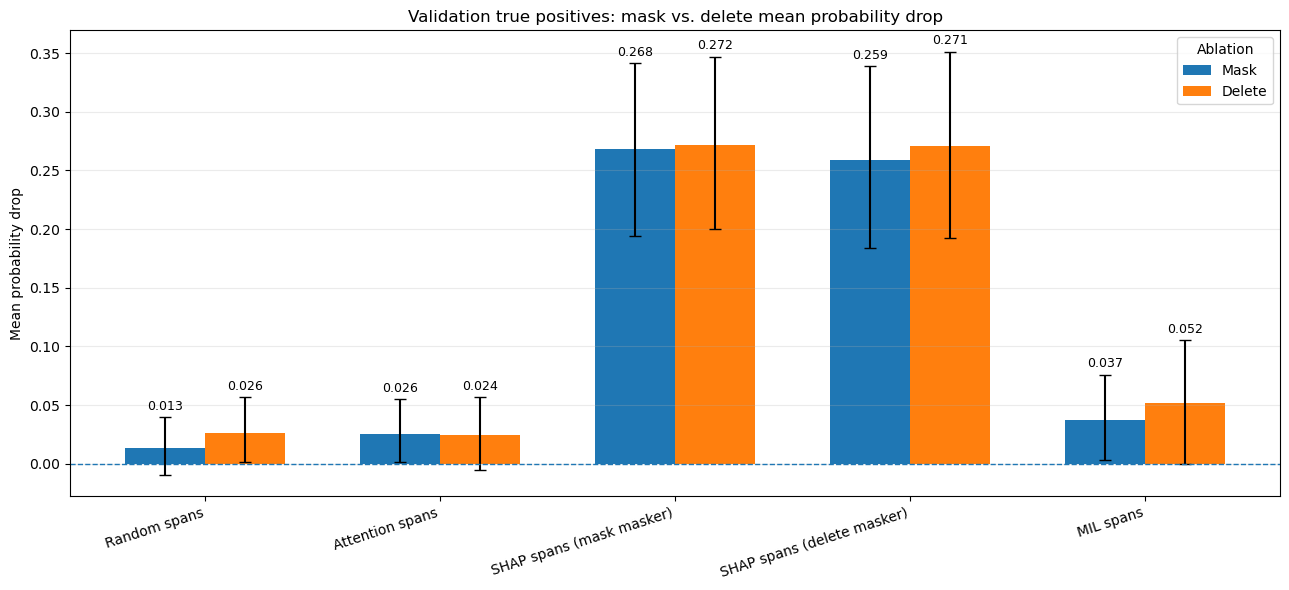

In [ ]:
# Mean probability drop with bootstrap confidence intervals.
x = np.arange(len(METHOD_ORDER), dtype=float)
width = 0.34
fig, ax = plt.subplots(figsize=(13, 6))
for offset_index, ablation_mode in enumerate(ABLATION_ORDER):
    subset = summary_argument_level.loc[summary_argument_level['ablation_mode'].eq(ablation_mode)].set_index('method').reindex(METHOD_ORDER)
    means = subset['mean_prob_drop'].to_numpy(dtype=float)
    lower = means - subset['mean_prob_drop_ci95_low'].to_numpy(dtype=float)
    upper = subset['mean_prob_drop_ci95_high'].to_numpy(dtype=float) - means
    positions = x + (offset_index - 0.5) * width
    bars = ax.bar(positions, means, width=width, yerr=np.vstack([lower, upper]), capsize=4, label=ablation_mode.capitalize())
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(0, linewidth=1, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER, rotation=18, ha='right')
ax.set_ylabel('Mean probability drop')
ax.set_title('Validation true positives: mask vs. delete mean probability drop')
ax.legend(title='Ablation')
ax.grid(axis='y', alpha=0.25)
save_current_figure('validation_tp_mean_probability_drop_mask_vs_delete.png')
plt.show()

Saved: ablation_comparison/plots/validation_tp_positive_drop_rate_mask_vs_delete.png


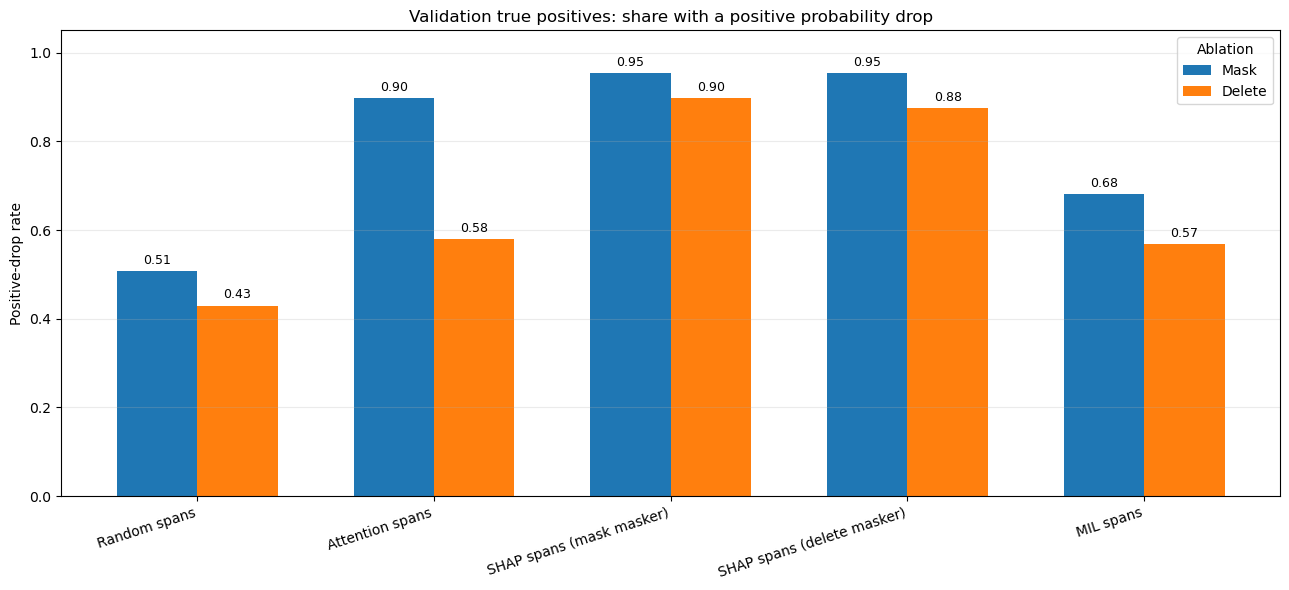

In [ ]:
# Positive-drop rate.
x = np.arange(len(METHOD_ORDER), dtype=float)
width = 0.34
fig, ax = plt.subplots(figsize=(13, 6))
for offset_index, ablation_mode in enumerate(ABLATION_ORDER):
    subset = summary_argument_level.loc[summary_argument_level['ablation_mode'].eq(ablation_mode)].set_index('method').reindex(METHOD_ORDER)
    values = subset['positive_drop_rate'].to_numpy(dtype=float)
    positions = x + (offset_index - 0.5) * width
    bars = ax.bar(positions, values, width=width, label=ablation_mode.capitalize())
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER, rotation=18, ha='right')
ax.set_ylabel('Positive-drop rate')
ax.set_title('Validation true positives: share with a positive probability drop')
ax.legend(title='Ablation')
ax.grid(axis='y', alpha=0.25)
save_current_figure('validation_tp_positive_drop_rate_mask_vs_delete.png')
plt.show()

/tmp/ipykernel_2133786/2643604524.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=labels, showmeans=True, meanline=True, showfliers=True)


Saved: ablation_comparison/plots/validation_tp_probability_drop_boxplots.png


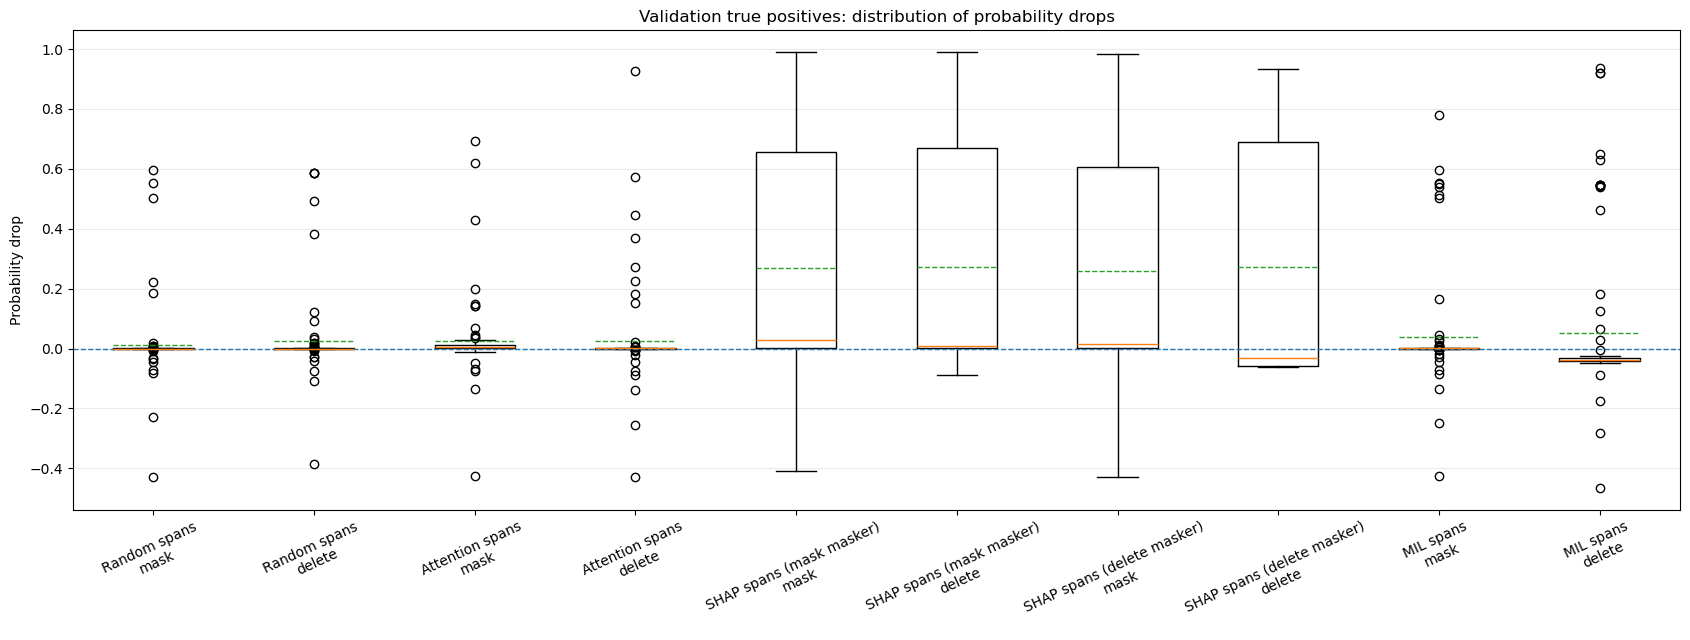

In [ ]:
# Probability-drop distributions.
labels, values = [], []
for method in METHOD_ORDER:
    for ablation_mode in ABLATION_ORDER:
        subset = results_argument_level.loc[
            results_argument_level['method'].eq(method) & results_argument_level['ablation_mode'].eq(ablation_mode), 'prob_drop'
        ].dropna()
        labels.append(f'{method}\n{ablation_mode}')
        values.append(subset.to_numpy())
fig, ax = plt.subplots(figsize=(17, 6.5))
ax.boxplot(values, labels=labels, showmeans=True, meanline=True, showfliers=True)
ax.axhline(0, linewidth=1, linestyle='--')
ax.set_ylabel('Probability drop')
ax.set_title('Validation true positives: distribution of probability drops')
ax.tick_params(axis='x', labelrotation=25)
ax.grid(axis='y', alpha=0.25)
save_current_figure('validation_tp_probability_drop_boxplots.png')
plt.show()

In [ ]:
shap = results_long_raw[
    results_long_raw['method'].str.startswith('SHAP spans')
].copy()

shap_tail = (
    shap.groupby(['method', 'ablation_mode'])['prob_drop']
    .apply(lambda x: pd.Series({
        'n': len(x),
        'n_negative': (x < 0).sum(),
        'share_negative_%': 100 * (x < 0).mean(),
        'mean_negative': x[x < 0].mean(),
        'median_negative': x[x < 0].median(),
        'min': x.min(),
        'sum_negative': x[x < 0].sum(),
        'mean_positive': x[x > 0].mean(),
    }))
    .unstack()
)

shap_tail.to_csv(TABLE_DIR / 'validation_tp_shap_ablation_tail_statistics.csv', index=True)
shap_tail

n  n_negative  share_negative_%  \
method                     ablation_mode                                       
SHAP spans (delete masker) delete         88.0        46.0         52.272727   
                           mask           88.0         4.0          4.545455   
SHAP spans (mask masker)   delete         88.0         9.0         10.227273   
                           mask           88.0         4.0          4.545455   

                                          mean_negative  median_negative  \
method                     ablation_mode                                   
SHAP spans (delete masker) delete             -0.055343        -0.058984   
                           mask               -0.110508        -0.006783   
SHAP spans (mask masker)   delete             -0.010424        -0.000599   
                           mask               -0.122858        -0.041435   

                                               min  sum_negative  \
method                     ablation_mode                           
SHAP spans (delete masker) delete        -0.062185     -2.545800   
                           mask          -0.427324     -0.442031   
SHAP spans (mask masker)   delete        -0.086745     -0.093818   
                           mask          -0.408214     -0.491434   

                                          mean_positive  
method                     ablation_mode                 
SHAP spans (delete masker) delete              0.628342  
                           mask                0.276742  
SHAP spans (mask masker)   delete              0.304162  
                           mask                0.286893

,method,ablation_mode,negative_drop_rate,n_arguments
0,Attention spans,delete,0.4091,88
1,Attention spans,mask,0.1023,88
2,MIL spans,delete,0.8182,88
3,MIL spans,mask,0.3182,88
4,Random spans,delete,0.5114,88
5,Random spans,mask,0.4091,88
6,SHAP spans (delete masker),delete,0.5227,88
7,SHAP spans (delete masker),mask,0.0455,88
8,SHAP spans (mask masker),delete,0.1023,88
9,SHAP spans (mask masker),mask,0.0455,88


Saved: /Users/karsten/Workspace/Localizing-Inappropriateness-in-Arguments/results/ablation_comparison/plots/validation_tp_negative_drop_rate_mask_vs_delete.png


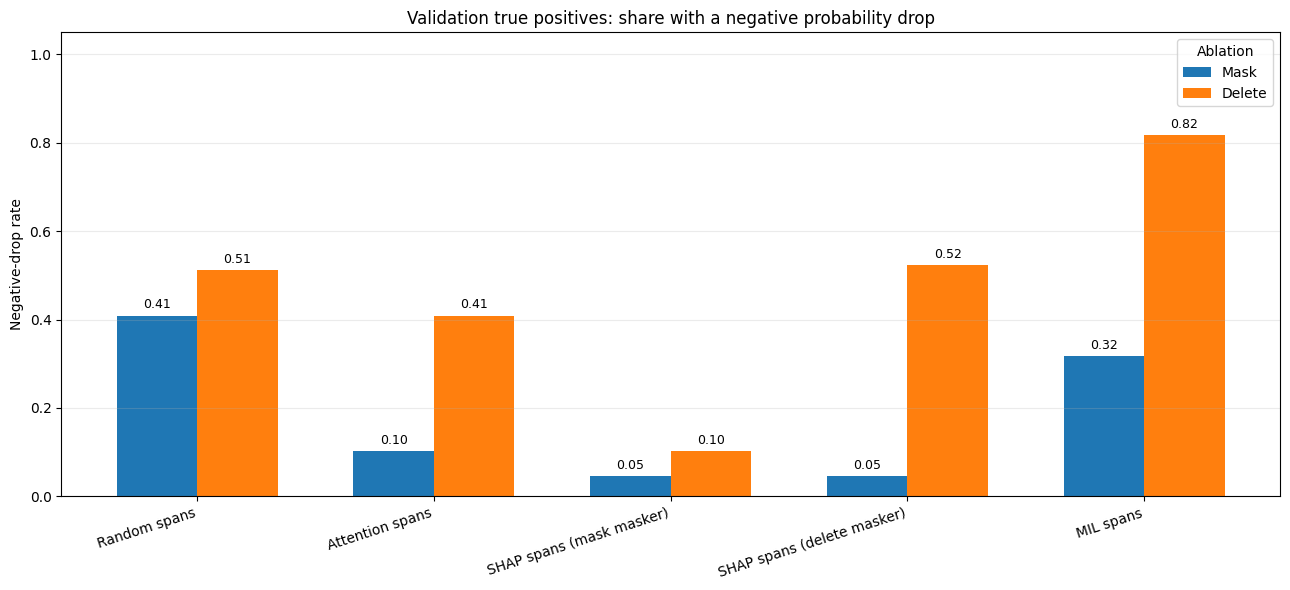

In [ ]:
# Plot: Negative-drop rate.
# A negative probability drop means that the perturbation increased
# the predicted probability of inappropriateness.
negative_drop_summary = (
    results_argument_level
    .assign(negative_drop=lambda df: df["prob_drop"] < 0)
    .groupby(["method", "ablation_mode"], as_index=False)
    .agg(
        negative_drop_rate=("negative_drop", "mean"),
        n_arguments=("global_row_id", "nunique"),
    )
)

display(negative_drop_summary.round(4))
negative_drop_summary.to_csv(TABLE_DIR / "validation_tp_negative_drop_rate_mask_vs_delete.csv", index=False)


x = np.arange(len(METHOD_ORDER), dtype=float)
width = 0.34

fig, ax = plt.subplots(figsize=(13, 6))

for offset_index, ablation_mode in enumerate(ABLATION_ORDER):
    subset = (
        negative_drop_summary.loc[
            negative_drop_summary["ablation_mode"].eq(ablation_mode)
        ]
        .set_index("method")
        .reindex(METHOD_ORDER)
    )

    values = subset["negative_drop_rate"].to_numpy(dtype=float)
    positions = x + (offset_index - 0.5) * width

    bars = ax.bar(
        positions,
        values,
        width=width,
        label=ablation_mode.capitalize(),
    )

    ax.bar_label(
        bars,
        fmt="%.2f",
        padding=3,
        fontsize=9,
    )

ax.set_ylim(0, 1.05)

ax.set_xticks(x)
ax.set_xticklabels(
    METHOD_ORDER,
    rotation=18,
    ha="right",
)

ax.set_ylabel("Negative-drop rate")
ax.set_title(
    "Validation true positives: share with a negative probability drop"
)

ax.legend(title="Ablation")
ax.grid(axis="y", alpha=0.25)

save_current_figure(
    "validation_tp_negative_drop_rate_mask_vs_delete.png"
)

plt.show()

Saved: ablation_comparison/plots/validation_tp_paired_scatter_random_spans.png


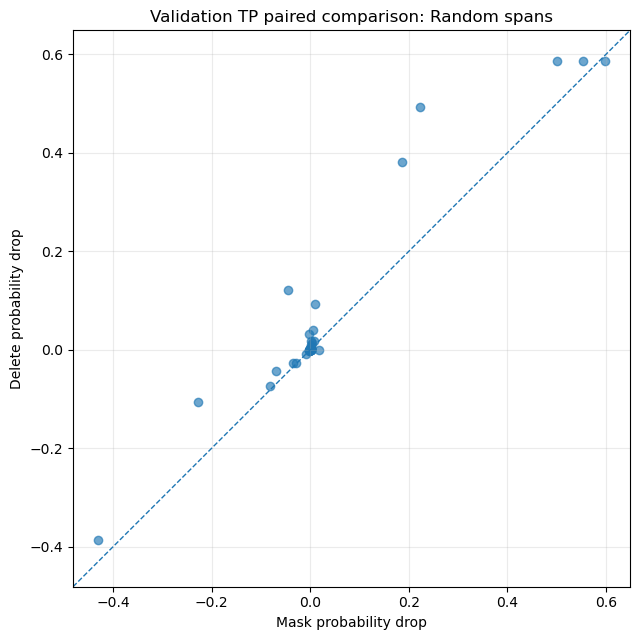

Saved: ablation_comparison/plots/validation_tp_paired_scatter_attention_spans.png


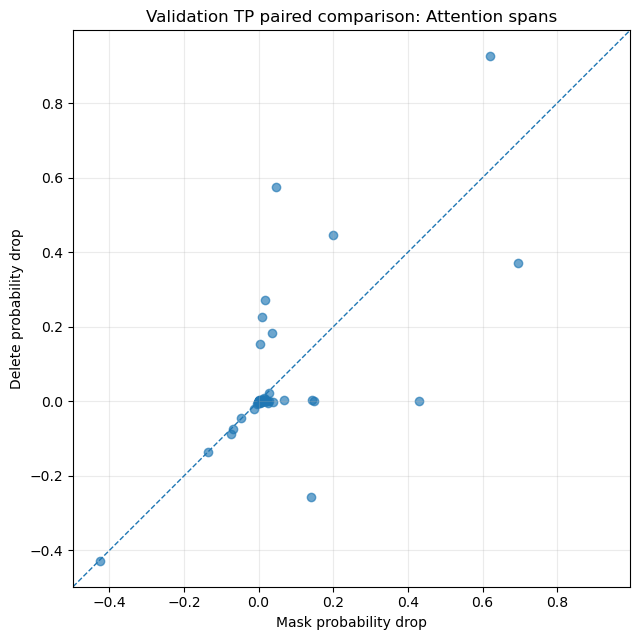

Saved: ablation_comparison/plots/validation_tp_paired_scatter_shap_spans_mask_masker.png


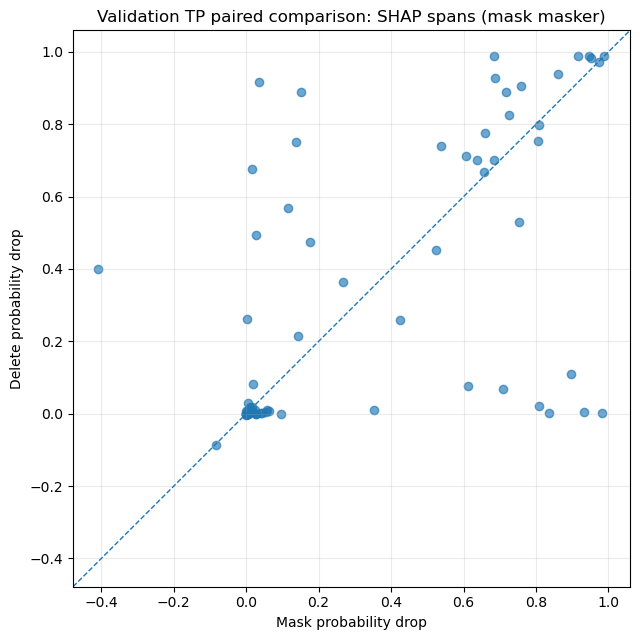

Saved: ablation_comparison/plots/validation_tp_paired_scatter_shap_spans_delete_masker.png


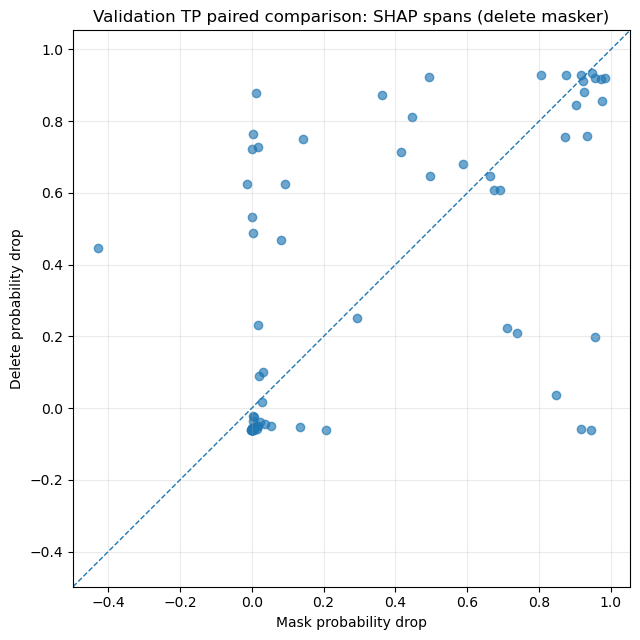

Saved: ablation_comparison/plots/validation_tp_paired_scatter_mil_spans.png


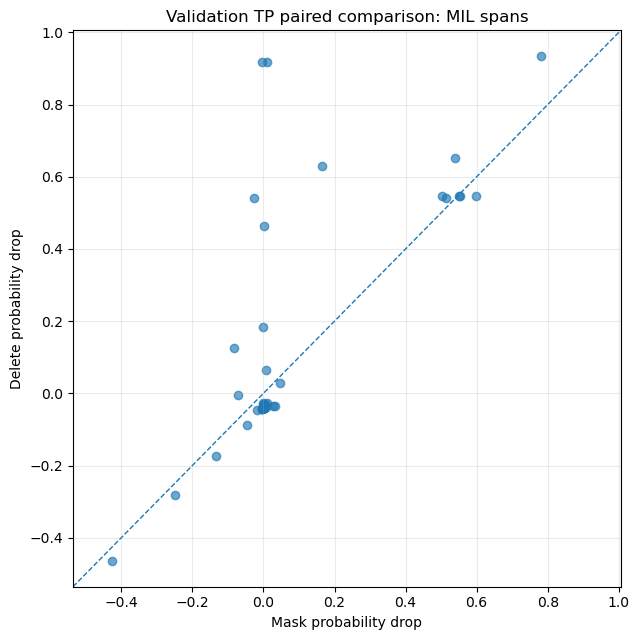

In [ ]:
# Paired scatter plots.
for method in METHOD_ORDER:
    pivot = results_argument_level.loc[results_argument_level['method'].eq(method)].pivot(
        index='global_row_id', columns='ablation_mode', values='prob_drop'
    ).dropna(subset=['mask', 'delete'])
    if pivot.empty:
        continue
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    ax.scatter(pivot['mask'], pivot['delete'], alpha=0.65)
    lower = float(np.nanmin(pivot[['mask', 'delete']].to_numpy()))
    upper = float(np.nanmax(pivot[['mask', 'delete']].to_numpy()))
    padding = max((upper - lower) * 0.05, 0.01)
    limits = [lower - padding, upper + padding]
    ax.plot(limits, limits, linestyle='--', linewidth=1)
    ax.set_xlim(limits); ax.set_ylim(limits)
    ax.set_xlabel('Mask probability drop'); ax.set_ylabel('Delete probability drop')
    ax.set_title(f'Validation TP paired comparison: {method}')
    ax.grid(alpha=0.25)
    slug = re.sub(r'[^a-z0-9]+', '_', method.lower()).strip('_')
    save_current_figure(f'validation_tp_paired_scatter_{slug}.png')
    plt.show()

Saved: ablation_comparison/plots/validation_tp_paired_difference_random_spans.png


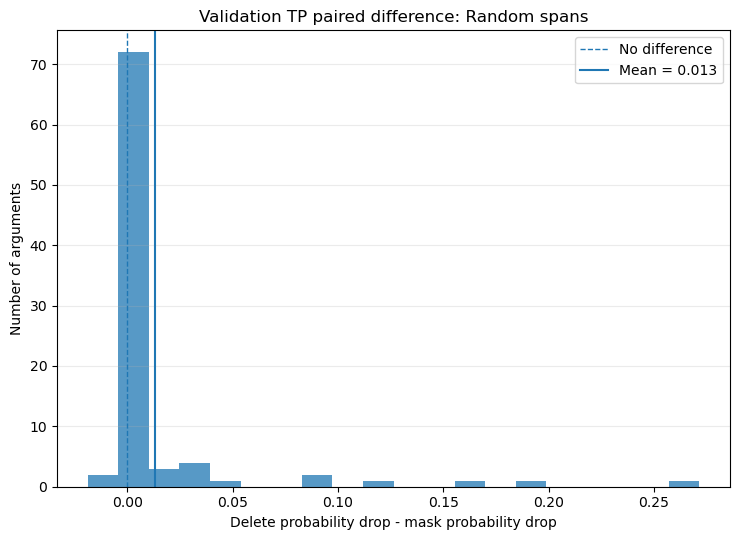

Saved: ablation_comparison/plots/validation_tp_paired_difference_attention_spans.png


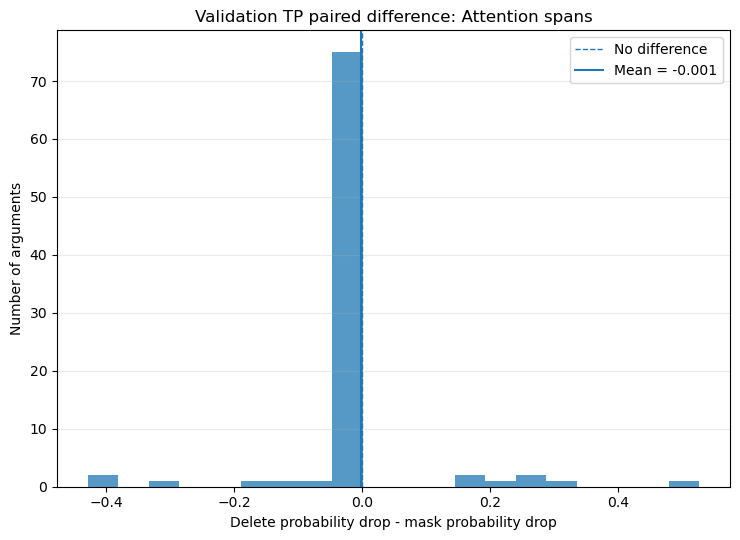

Saved: ablation_comparison/plots/validation_tp_paired_difference_shap_spans_mask_masker.png


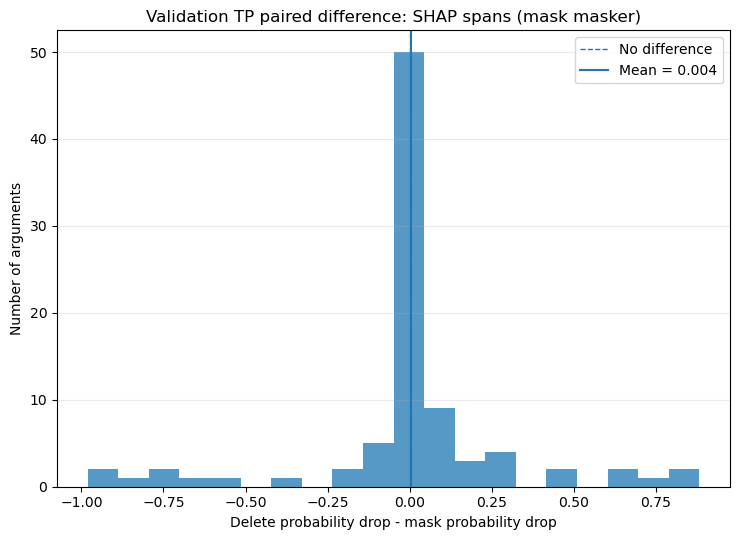

Saved: ablation_comparison/plots/validation_tp_paired_difference_shap_spans_delete_masker.png


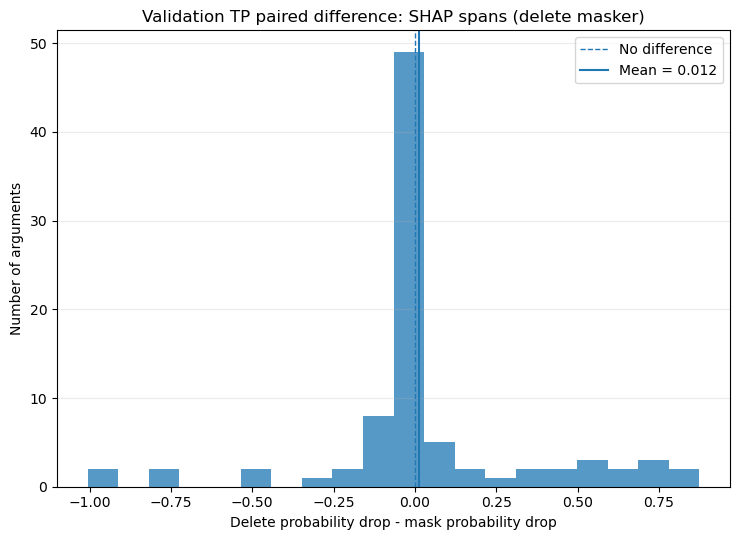

Saved: ablation_comparison/plots/validation_tp_paired_difference_mil_spans.png


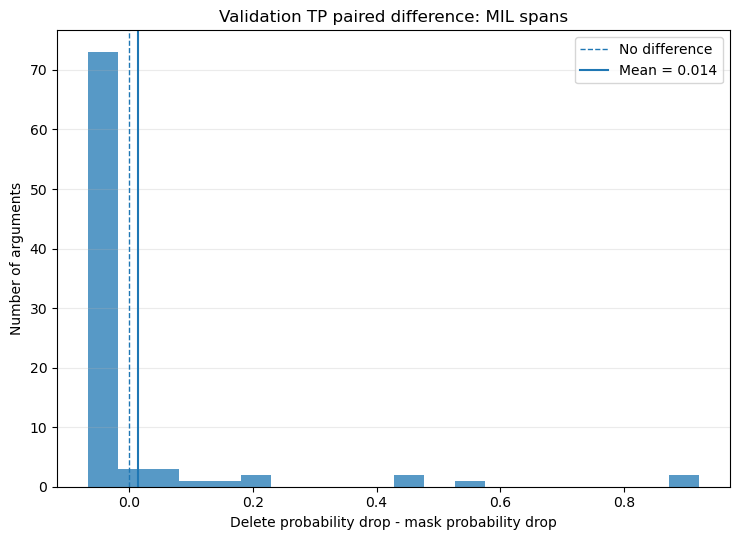

In [ ]:
# Paired delete-minus-mask distributions.
for method in METHOD_ORDER:
    pivot = results_argument_level.loc[results_argument_level['method'].eq(method)].pivot(
        index='global_row_id', columns='ablation_mode', values='prob_drop'
    ).dropna(subset=['mask', 'delete'])
    if pivot.empty:
        continue
    differences = pivot['delete'] - pivot['mask']
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    ax.hist(differences, bins=20, alpha=0.75)
    ax.axvline(0, linewidth=1, linestyle='--', label='No difference')
    ax.axvline(differences.mean(), linewidth=1.5, label=f'Mean = {differences.mean():.3f}')
    ax.set_xlabel('Delete probability drop - mask probability drop')
    ax.set_ylabel('Number of arguments')
    ax.set_title(f'Validation TP paired difference: {method}')
    ax.legend(); ax.grid(axis='y', alpha=0.25)
    slug = re.sub(r'[^a-z0-9]+', '_', method.lower()).strip('_')
    save_current_figure(f'validation_tp_paired_difference_{slug}.png')
    plt.show()

## 13. Save tables and metadata

In [ ]:
results_long_raw.to_csv(TABLE_DIR / 'validation_tp_mask_vs_delete_long_row_level.csv', index=False)
results_argument_level.to_csv(TABLE_DIR / 'validation_tp_mask_vs_delete_argument_level.csv', index=False)
summary_argument_level.to_csv(TABLE_DIR / 'validation_tp_mask_vs_delete_summary.csv', index=False)
paired_summary.to_csv(TABLE_DIR / 'validation_tp_mask_vs_delete_paired_statistics.csv', index=False)
empty_delete_table.to_csv(TABLE_DIR / 'validation_tp_empty_deleted_texts.csv', index=False)
mil_history_df.to_csv(TABLE_DIR / 'validation_tp_mil_training_history.csv', index=False)

configuration_table = pd.DataFrame([
    {'method': 'Random spans', 'configuration': f'mode={RANDOM_SELECTION_MODE};span_length={RANDOM_SPAN_LENGTH};samples={RANDOM_SAMPLES_PER_ARGUMENT}', 'selection_basis': 'fixed a priori'},
    {'method': 'Attention spans', 'configuration': f'method={ATTENTION_METHOD};quantile={ATTENTION_QUANTILE};window_size={ATTENTION_WINDOW_SIZE}', 'selection_basis': f'uniform random draw from predefined space; seed={SEED}'},
    {'method': 'SHAP spans (mask masker)', 'configuration': f'masker=mask;quantile={SHAP_QUANTILE};window_size={SHAP_WINDOW_SIZE}', 'selection_basis': 'fixed a priori'},
    {'method': 'SHAP spans (delete masker)', 'configuration': f'masker=delete;quantile={SHAP_QUANTILE};window_size={SHAP_WINDOW_SIZE}', 'selection_basis': 'fixed a priori'},
    {'method': 'MIL spans', 'configuration': f'pooling={MIL_POOLING_MODE};span_lengths={MIL_SPAN_LENGTHS};stride={MIL_STRIDE};max_candidates={MIL_MAX_CANDIDATES};epochs={MIL_NUM_EPOCHS};top_n={MIL_TOP_N_SPANS}', 'selection_basis': 'uniform random draw from predefined space; trained on train split only'},
])
configuration_table.to_csv(TABLE_DIR / 'validation_tp_study_configurations.csv', index=False)

metadata = {
    'seed': SEED, 'model_name': MODEL_NAME, 'device': str(DEVICE), 'validation_tp_count': int(len(val_tp_df)),
    'max_length': MAX_LENGTH, 'mask_token': MASK_TOKEN, 'inappropriate_label_id': INAPPROPRIATE_LABEL_ID,
    'random': {'selection_mode': RANDOM_SELECTION_MODE, 'span_length': RANDOM_SPAN_LENGTH, 'samples_per_argument': RANDOM_SAMPLES_PER_ARGUMENT},
    'attention': {'method': ATTENTION_METHOD, 'quantile': ATTENTION_QUANTILE, 'window_size': ATTENTION_WINDOW_SIZE,
                  'space': {'methods': ATTENTION_METHODS, 'quantiles': QUANTILE_VALUES, 'window_sizes': WINDOW_SIZE_VALUES}},
    'shap': {'quantile': SHAP_QUANTILE, 'window_size': SHAP_WINDOW_SIZE, 'masker_modes': SHAP_MASKER_MODES},
    'mil': {'pooling_mode': MIL_POOLING_MODE, 'span_lengths': list(MIL_SPAN_LENGTHS), 'stride': MIL_STRIDE,
            'max_candidates': MIL_MAX_CANDIDATES, 'num_epochs': MIL_NUM_EPOCHS, 'freeze_encoder': MIL_FREEZE_ENCODER,
            'top_n_spans': MIL_TOP_N_SPANS},
    'bootstrap_resamples': N_BOOTSTRAP,
}
with (TABLE_DIR / 'validation_tp_mask_vs_delete_metadata.json').open('w', encoding='utf-8') as handle:
    json.dump(json_safe(metadata), handle, indent=2, ensure_ascii=False)

print('Tables:', TABLE_DIR)
print('Plots:', PLOT_DIR)
display(configuration_table)

## Selection of the Common Ablation Operator

The validation experiment does not show that masking universally produces larger probability drops than deletion. In fact, deletion yields a slightly larger **mean** probability drop for several span sources, including Random, MIL, and both SHAP variants. For example, the mean drop for MIL is approximately 0.052 under deletion compared with 0.038 under masking, while the two SHAP variants show only small differences in their average drops. Attention is the only span source for which the mean drop is marginally larger under masking. Consequently, the choice of the ablation operator is **not** based on maximizing the average probability drop.

The argument-level results instead indicate that masking produces the expected direction of change more **consistently**. Across all five span sources, the positive-drop rate is higher under masking than under deletion. The same tendency is visible in the paired analysis: masking produces the larger probability drop for the majority of individual arguments for every span source, with mask win rates ranging from approximately 53% for Random spans to approximately 90% for Attention spans. The median paired difference, defined as $\Delta p_{\mathrm{delete}}-\Delta p_{\mathrm{mask}}$, is also non-positive for all five span sources. Thus, although a smaller number of deletion cases can produce comparatively large probability changes and thereby increase the mean, the typical paired comparison tends to favor masking.

The negative-drop analysis supports this interpretation. A negative probability drop means that perturbing the selected evidence makes the classifier **more**, rather than less, confident in the inappropriate class. Such behavior occurs less frequently under masking for every investigated span source. The difference is particularly pronounced for Attention, MIL, and the SHAP variant constructed with the delete masker. For the latter, only approximately 4.5% of arguments show a negative drop under masking, compared with approximately 52.3% under deletion. For the SHAP spans generated with the mask masker, the corresponding rates are approximately 4.5% and 10.2%.

At the same time, the distribution plots reveal an important limitation of this conclusion. Masking is not free from undesirable perturbation effects. In particular, the SHAP distributions contain a small number of comparatively strong negative outliers under masking, and these individual negative drops can be more extreme than those observed under deletion. The lower overall negative-drop rate therefore does not imply that masking produces uniformly smaller negative effects. Rather, the results suggest a distinction between **frequency and magnitude**: negative reactions can occasionally be pronounced under masking, but they occur for substantially fewer arguments, whereas deletion causes changes in the unintended direction more frequently.

Taken together, the experiment therefore provides no basis for claiming that masking is intrinsically superior to deletion or that it always produces stronger perturbation effects. Instead, masking is selected as the common ablation operator because its effects are more directionally consistent across the heterogeneous span sources considered in this study. This empirical observation complements the methodological motivation for masking: replacing the selected model tokens explicitly removes their lexical information while largely preserving the token-sequence structure, whereas deletion additionally shortens the input and introduces new token adjacencies. Since the objective of the subsequent experiments is to evaluate the effect of making selected evidence unavailable rather than to maximize the magnitude of the resulting classifier change, masking provides the more controlled common perturbation operator for the remainder of the thesis.

Accordingly, **masking is fixed as the ablation operator for all subsequent perturbation-based evaluations on the held-out test set**. This choice should be understood as an empirically supported experimental design decision for the present classifier and evaluation setting, rather than as a general claim that masking is preferable to deletion for explanation evaluation in all language models or tasks.